# Cryptocurrency Forecasting — Facebook Prophet
This notebook implements Facebook Prophet to forecast the next 180 days
of closing prices for 10 major cryptocurrencies. It uses log-transformed
prices, volume as an external regressor, per-crypto tuned changepoint
scales, and cross-validation on BTC to evaluate model robustness.

**Key Features:**
- Log transformation to handle exponential price growth
- Volume scaled regressor for improved accuracy
- Monthly and quarterly custom seasonality components
- Per-cryptocurrency tuned changepoint prior scales
- 90-day train/test evaluation before full retraining

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

os.makedirs("../data/forecasts/prophet", exist_ok=True)

g:\My Drive\crypto project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Load Dataset
Load the preprocessed combined cryptocurrency dataset from `data/processed/`.

In [ ]:
df = pd.read_csv("../data/processed/combined_crypto_data.csv", parse_dates=["Date"])

print("Shape:", df.shape)
print("Cryptos:", df["Crypto"].unique())
df.head()

Shape: (18250, 14)
Cryptos: ['ADA' 'BNB' 'BTC' 'DOGE' 'DOT' 'ETH' 'LINK' 'LTC' 'SOL' 'XRP']


,Date,Open,High,Low,Close,Volume,Crypto,Daily_Return,Log_Return,Price_Range,MA_7,MA_30,Volatility_7,Cumulative_Return
0,2021-01-01,0.181382,0.184246,0.172022,0.175350,1122218004,ADA,NaN,NaN,0.012224,NaN,NaN,NaN,0.000000
1,2021-01-02,0.175359,0.184253,0.169233,0.177423,1408849504,ADA,1.182210,0.011753,0.015020,NaN,NaN,NaN,1.182210
2,2021-01-03,0.177382,0.208679,0.173376,0.204995,2303857909,ADA,15.540266,0.144449,0.035303,NaN,NaN,NaN,16.906194
3,2021-01-04,0.205236,0.239661,0.194450,0.224762,3260699086,ADA,9.642667,0.092056,0.045211,NaN,NaN,NaN,28.179070
4,2021-01-05,0.224817,0.264886,0.208454,0.258314,4097207384,ADA,14.927800,0.139134,0.056432,NaN,NaN,NaN,47.313385


## Data Preparation — Log Transform + Volume Regressor
Prophet requires input columns named `ds` (date) and `y` (target value).

**Two key transformations applied:**
- **Log Transform on Close price:** Cryptocurrency prices grow exponentially.
  Log transformation linearizes this growth making it easier for Prophet to model.
  Predictions are converted back using `exp()` after forecasting.
- **Volume Scaling:** Trading volume is normalized (zero mean, unit variance)
  and used as an external regressor to capture volume-driven price movements.

In [ ]:
def prepare_prophet_data(df, crypto):
    crypto_df = df[df["Crypto"] == crypto][["Date", "Close", "Volume"]].copy()
    crypto_df = crypto_df.rename(columns={"Date": "ds", "Close": "y"})
    crypto_df = crypto_df.sort_values("ds").reset_index(drop=True)

    # Log transform price to handle exponential growth
    crypto_df["y"] = np.log(crypto_df["y"])

    # Normalize volume (used as regressor)
    crypto_df["volume_scaled"] = (
        crypto_df["Volume"] - crypto_df["Volume"].mean()
    ) / crypto_df["Volume"].std()

    return crypto_df

## Per-Crypto Changepoint Prior Scales
The `changepoint_prior_scale` controls how flexible the trend is.

| Value | Effect |
|-------|--------|
| Low (0.05) | Smooth, stable trend — good for BTC, ETH |
| Medium (0.08–0.15) | Moderate flexibility — good for BNB, LTC, SOL |
| High (0.20–0.25) | Highly flexible trend — good for DOT, XRP, DOGE |

Higher values allow the model to fit more trend changes but risk overfitting.
Each cryptocurrency has been assigned a scale based on its historical volatility profile.

In [ ]:
# Higher value = more flexible trend (better for volatile coins)
CHANGEPOINT_SCALES = {
    "BTC":  0.05,   
    "ETH":  0.05,   
    "BNB":  0.08,
    "SOL":  0.15,   
    "LTC":  0.08,
    "LINK": 0.15,
    "DOT":  0.20,   
    "XRP":  0.20,
    "ADA":  0.20,
    "DOGE": 0.25,   
}

## Build Prophet Model
Constructs a Prophet model with the following configuration:

| Parameter | Value | Reason |
|-----------|-------|--------|
| seasonality_mode | multiplicative | Crypto volatility scales with price level |
| yearly_seasonality | True | Annual market cycles |
| weekly_seasonality | True | Weekend trading patterns |
| daily_seasonality | False | Not applicable for daily data |
| interval_width | 0.95 | 95% confidence interval bands |
| monthly seasonality | fourier_order=5 | Monthly trading cycles |
| quarterly seasonality | fourier_order=7 | Quarterly market cycles |

In [ ]:
def build_prophet_model(crypto):
    cp_scale = CHANGEPOINT_SCALES.get(crypto, 0.1)

    model = Prophet(
        changepoint_prior_scale=cp_scale,
        seasonality_prior_scale=10,
        seasonality_mode="multiplicative",
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        interval_width=0.95
    )

    # Add monthly & quarterly seasonality
    model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    model.add_seasonality(name="quarterly", period=91.25, fourier_order=7)

    # Add volume as external regressor
    model.add_regressor("volume_scaled")

    return model

## Model Evaluation Function
Evaluates predictions on the **original price scale** by converting
log predictions back using `exp()` before computing metrics.

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| MAE | mean(actual - predicted) | Average absolute error in USD |
| RMSE | sqrt(mean((actual - predicted)²)) | Penalizes large errors more |
| MAPE | mean((actual - predicted) / actual) × 100 | % error — scale independent |

In [ ]:
def evaluate_model(actual_log, predicted_log):
    # Convert back from log scale
    actual    = np.exp(actual_log)
    predicted = np.exp(predicted_log)

    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {"MAE": round(mae, 4), "RMSE": round(rmse, 4), "MAPE": round(mape, 4)}

## Forecast Plot Function
Generates a two-panel forecast chart per cryptocurrency:
- **Top panel:** Full historical price + complete forecast with confidence interval
- **Bottom panel:** Future 180-day forecast only with confidence interval

The red dashed vertical line marks the boundary between historical data and forecast.
All values are converted back from log scale to original USD prices for readability.

In [ ]:
def plot_forecast(crypto, prophet_df, forecast, output_dir):
    # Convert back from log scale for plotting
    actual_price   = np.exp(prophet_df["y"])
    forecast_price = np.exp(forecast["yhat"])
    lower_price    = np.exp(forecast["yhat_lower"])
    upper_price    = np.exp(forecast["yhat_upper"])

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Plot 1: Full history + forecast
    axes[0].plot(prophet_df["ds"], actual_price, label="Actual", color="steelblue", linewidth=1.5)
    axes[0].plot(forecast["ds"], forecast_price, label="Forecast", color="orange", linewidth=1.5)
    axes[0].fill_between(forecast["ds"], lower_price, upper_price,
                         alpha=0.2, color="orange", label="95% Confidence Interval")
    axes[0].axvline(prophet_df["ds"].max(), color="red", linestyle="--", linewidth=1, label="Forecast Start")
    axes[0].set_title(f"{crypto} - Prophet Forecast (180 Days)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Price (USD)")
    axes[0].legend()

    # Plot 2: Future only
    future_mask     = forecast["ds"] > prophet_df["ds"].max()
    future_forecast = forecast[future_mask]
    axes[1].plot(future_forecast["ds"], np.exp(future_forecast["yhat"]),
                 color="orange", linewidth=2, label="Forecast")
    axes[1].fill_between(future_forecast["ds"],
                         np.exp(future_forecast["yhat_lower"]),
                         np.exp(future_forecast["yhat_upper"]),
                         alpha=0.3, color="orange", label="95% Confidence Interval")
    axes[1].set_title(f"{crypto} - Next 180 Days Forecast", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Price (USD)")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{crypto}_forecast.png", dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {crypto}_forecast.png")

## Components Plot Function
Prophet decomposes the forecast into individual components:
- **Trend:** Long-term price direction
- **Weekly seasonality:** Day-of-week patterns
- **Monthly seasonality:** Monthly trading cycles
- **Quarterly seasonality:** Quarterly market cycles
- **Volume regressor effect:** Impact of trading volume on price

These components help interpret *why* the model makes specific predictions.

In [ ]:
def plot_components(crypto, model, forecast, output_dir):
    fig = model.plot_components(forecast)
    plt.suptitle(f"{crypto} - Forecast Components", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{crypto}_components.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {crypto}_components.png")

## Main Training Loop — All 10 Cryptocurrencies
For each cryptocurrency the following steps are executed:

1. **Prepare data** — log transform + volume scaling
2. **Train/test split** — last 90 days held out for evaluation
3. **Train on train set** — fit Prophet model on training data
4. **Evaluate on test set** — compute MAE, RMSE, MAPE on original price scale
5. **Retrain on full data** — refit model using all available data
6. **Forecast 180 days** — generate future predictions with confidence intervals
7. **Save outputs** — forecast CSV, forecast plot, components plot

> This two-stage approach (evaluate then retrain) ensures honest
> performance metrics while using maximum data for the final forecast.


Training Prophet for: ADA
----------------------------------------


15:32:38 - cmdstanpy - INFO - Chain [1] start processing
15:32:43 - cmdstanpy - INFO - Chain [1] done processing


MAE: 0.3784  |  RMSE: 0.4104  |  MAPE: 83.889%


15:32:44 - cmdstanpy - INFO - Chain [1] start processing
15:32:47 - cmdstanpy - INFO - Chain [1] done processing


Saved: ADA_forecast.csv


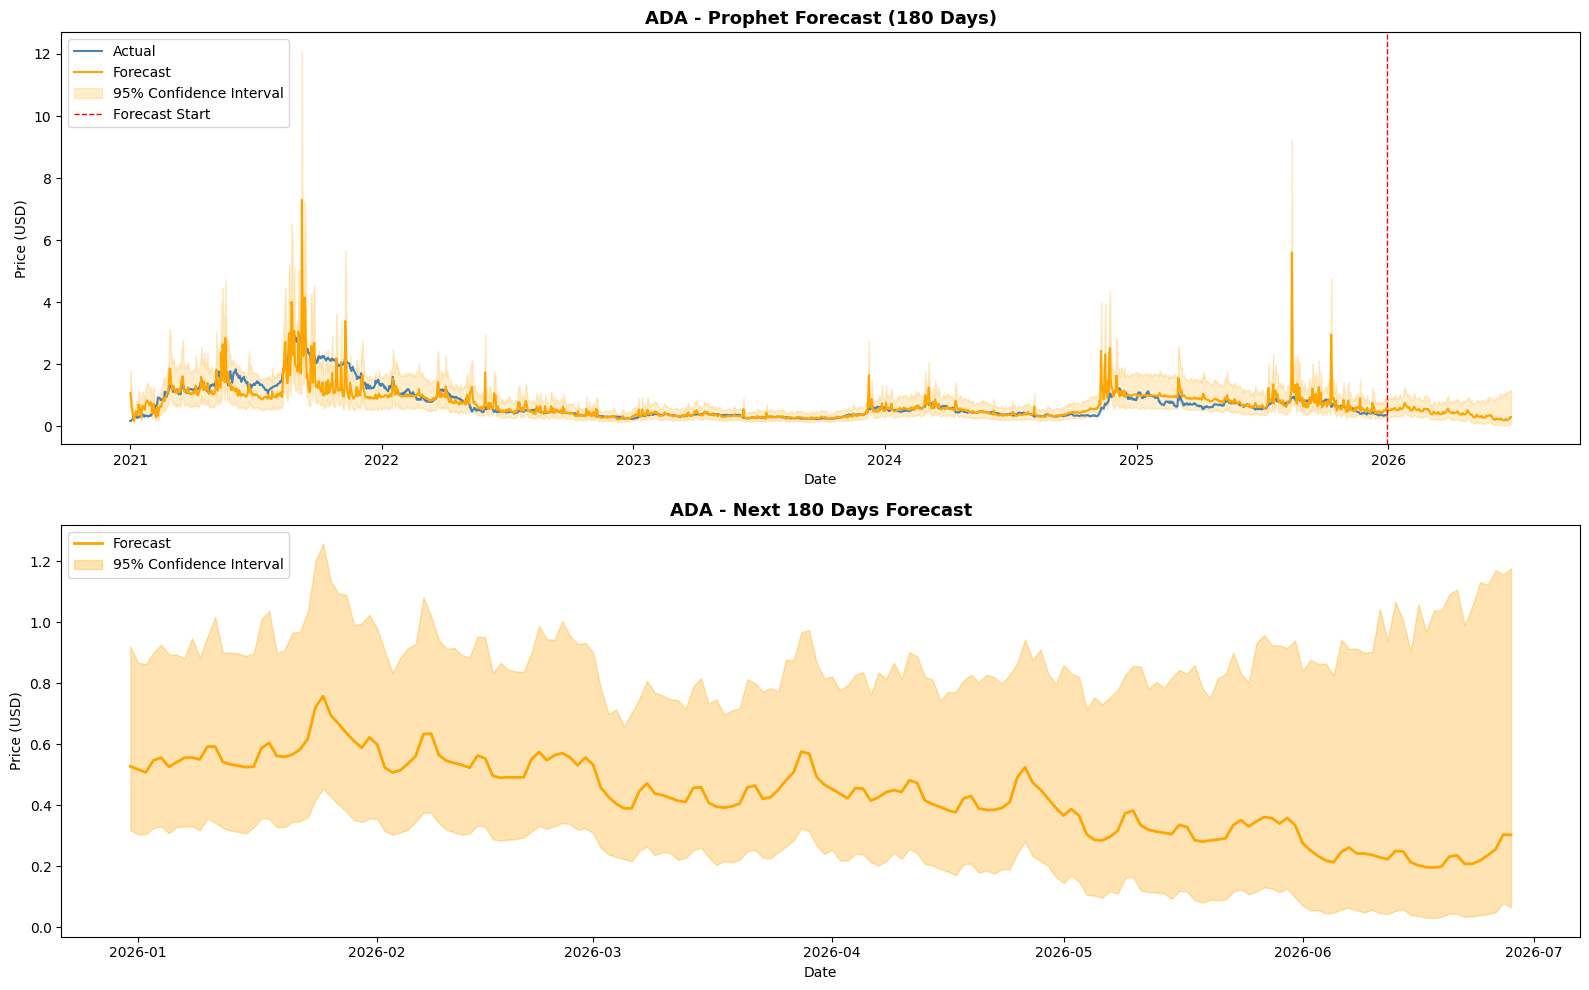

Saved: ADA_forecast.png


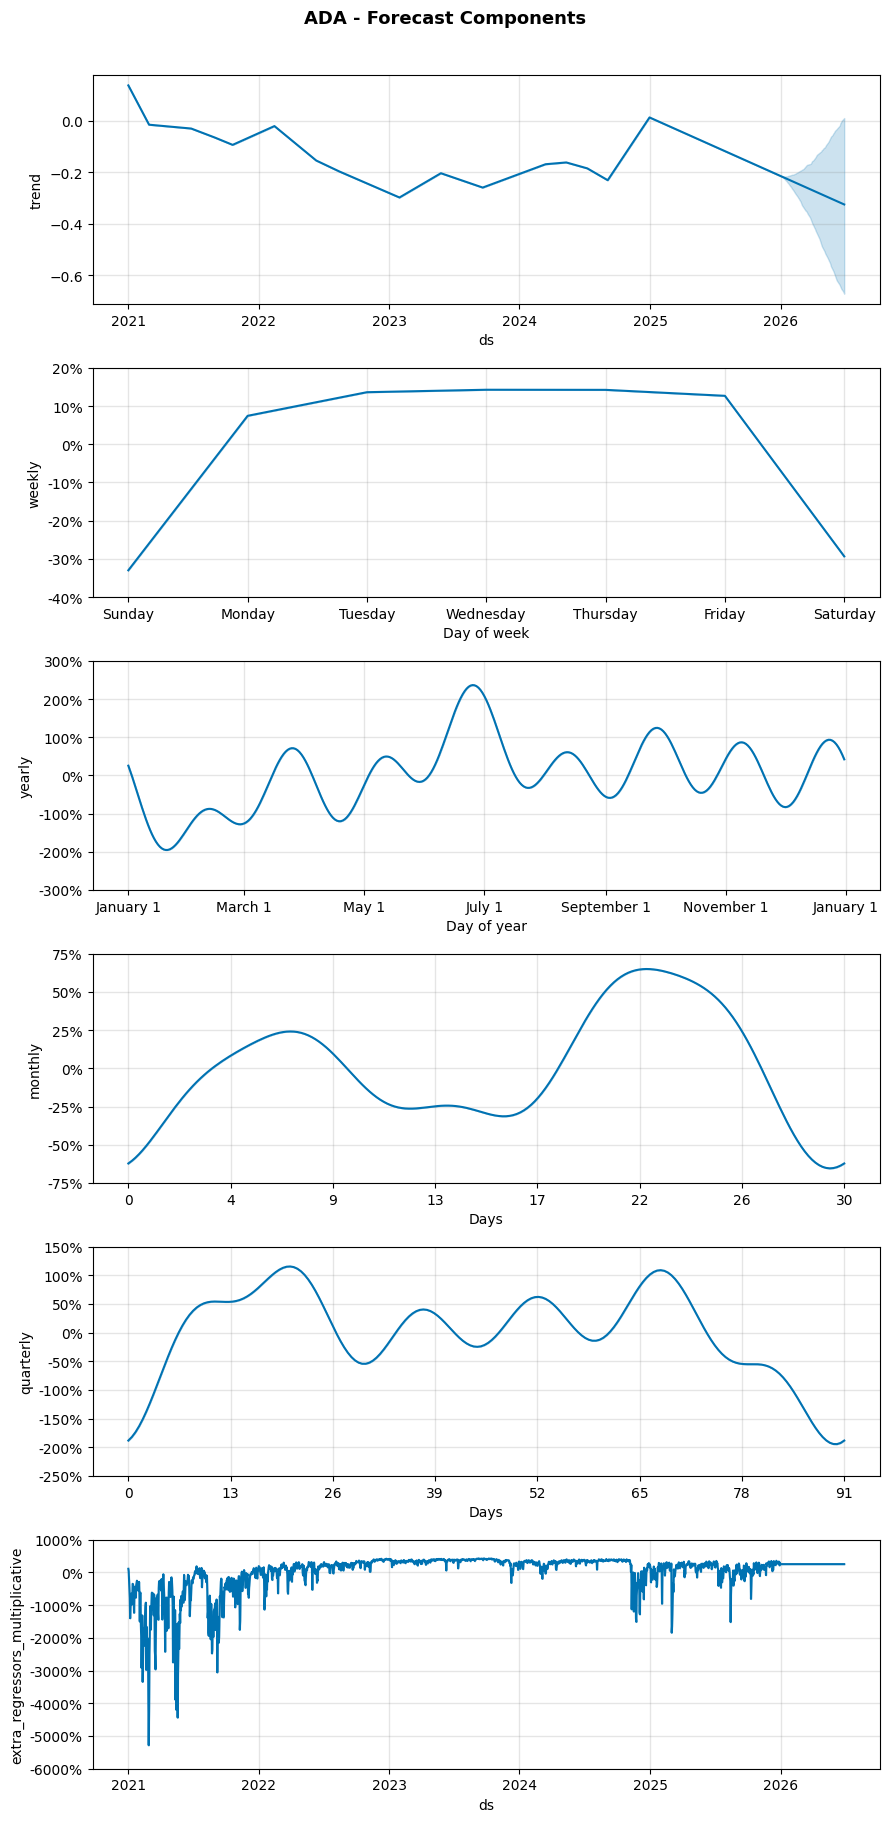

Saved: ADA_components.png

Training Prophet for: BNB
----------------------------------------


15:33:00 - cmdstanpy - INFO - Chain [1] start processing
15:33:02 - cmdstanpy - INFO - Chain [1] done processing


MAE: 190.7297  |  RMSE: 218.641  |  MAPE: 20.5249%


15:33:04 - cmdstanpy - INFO - Chain [1] start processing
15:33:07 - cmdstanpy - INFO - Chain [1] done processing


Saved: BNB_forecast.csv


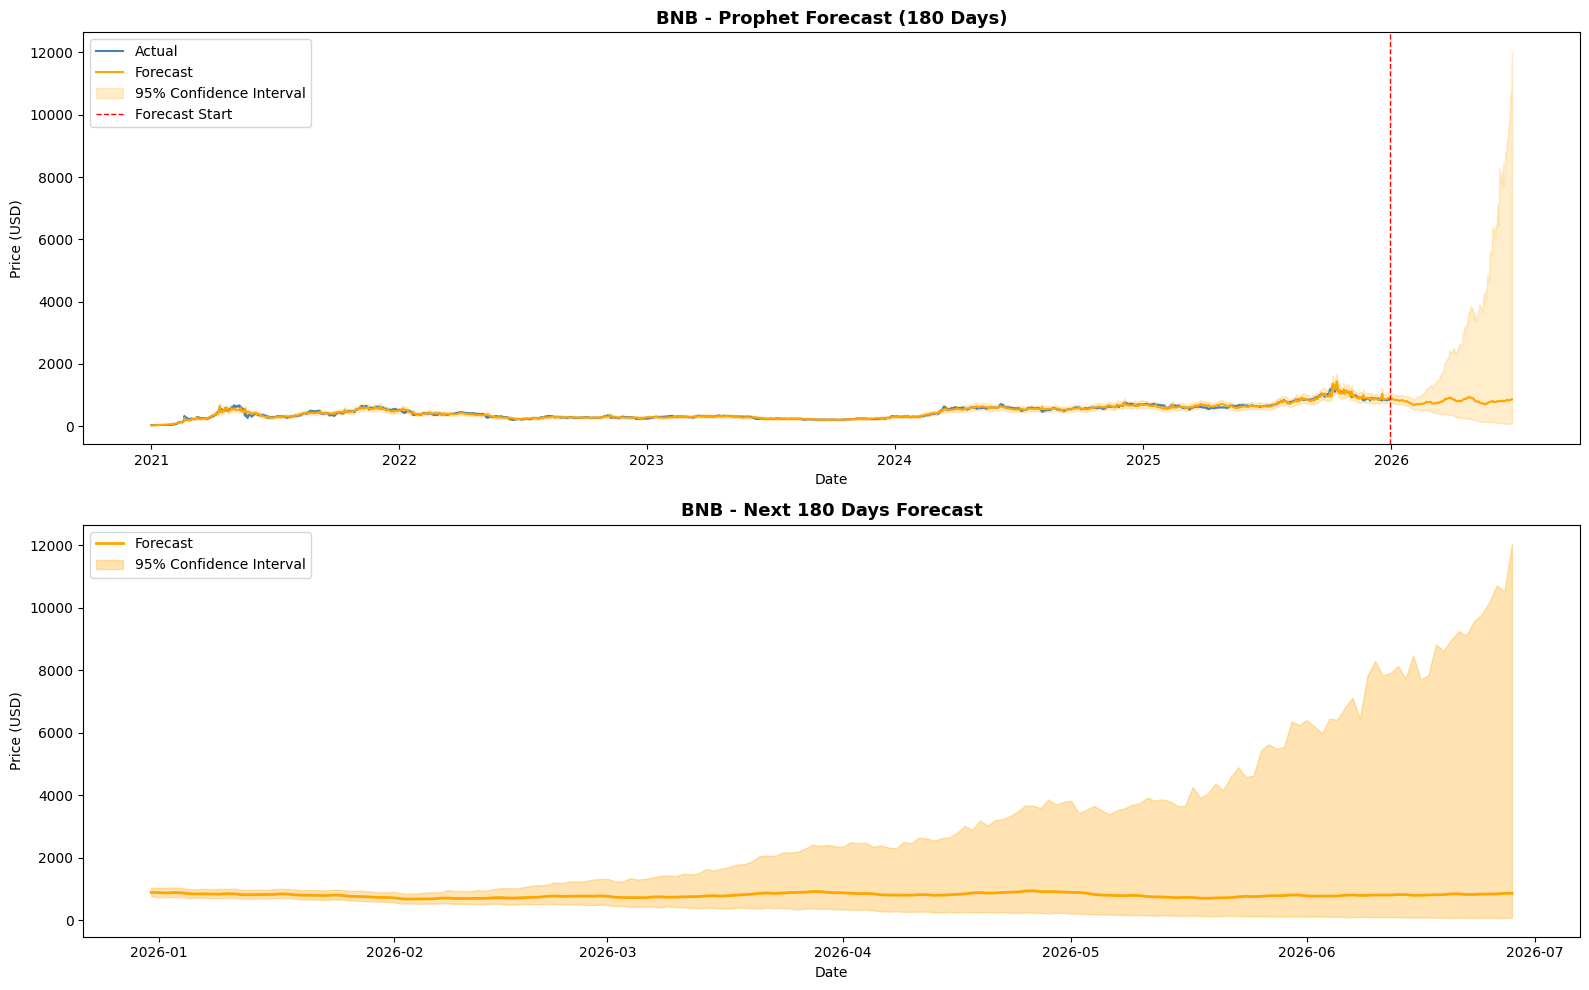

Saved: BNB_forecast.png


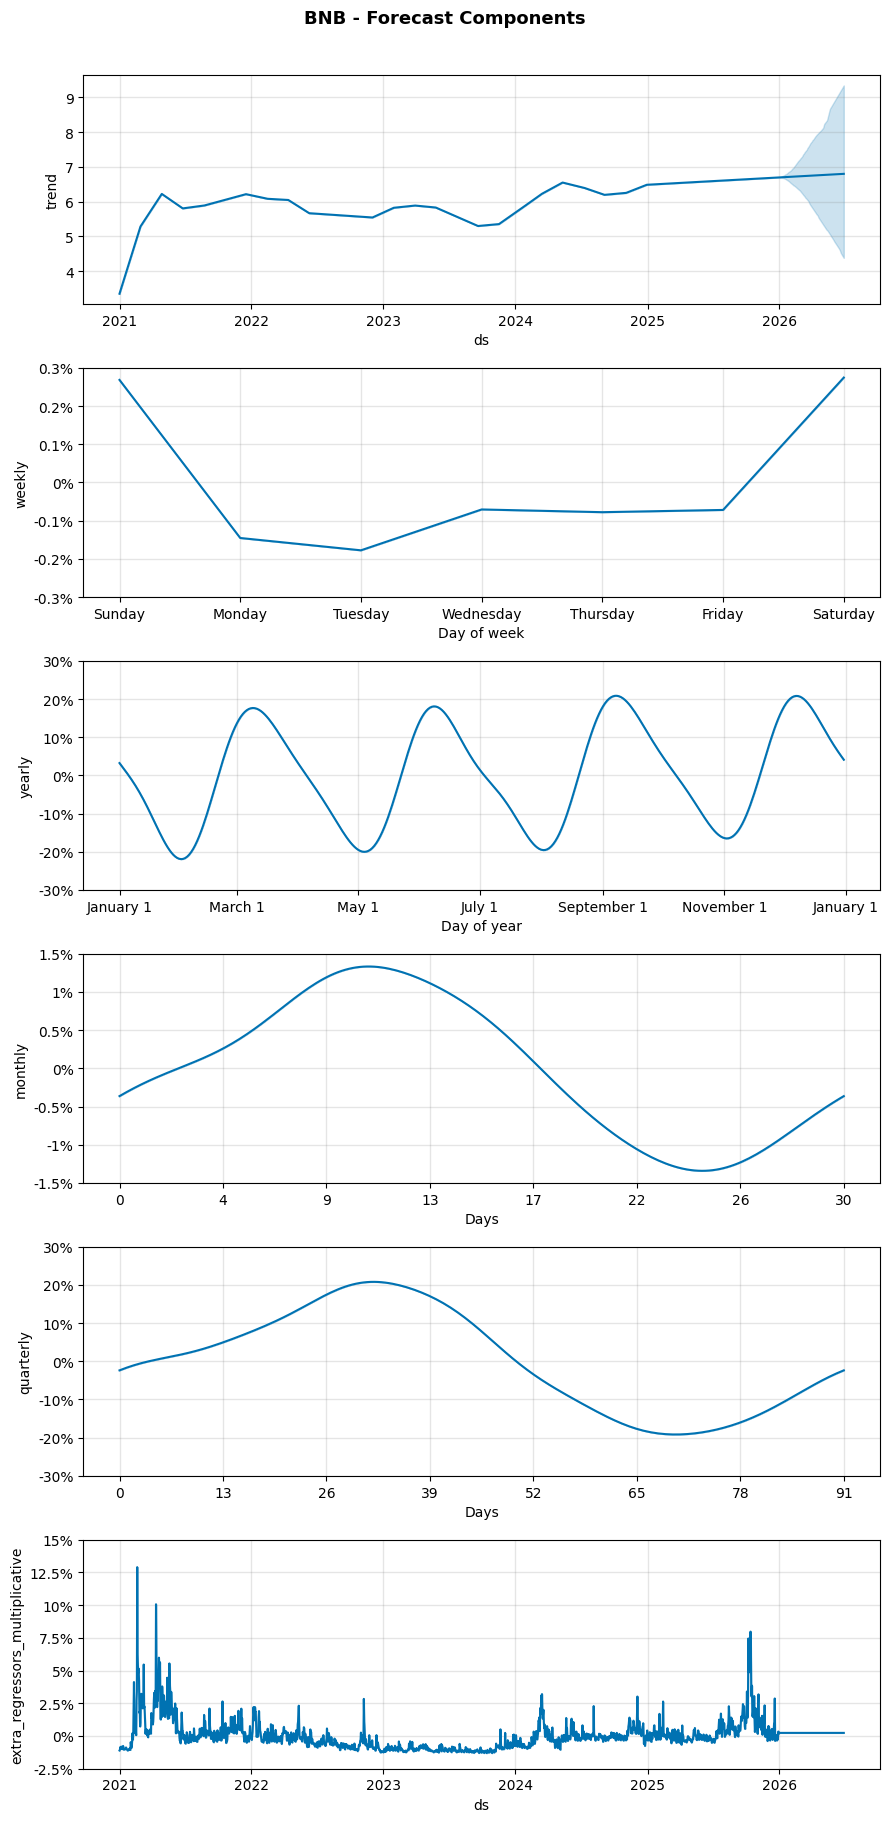

Saved: BNB_components.png

Training Prophet for: BTC
----------------------------------------


15:33:20 - cmdstanpy - INFO - Chain [1] start processing
15:33:25 - cmdstanpy - INFO - Chain [1] done processing


MAE: 64349.3805  |  RMSE: 72346.5161  |  MAPE: 69.1537%


15:33:27 - cmdstanpy - INFO - Chain [1] start processing
15:33:31 - cmdstanpy - INFO - Chain [1] done processing


Saved: BTC_forecast.csv


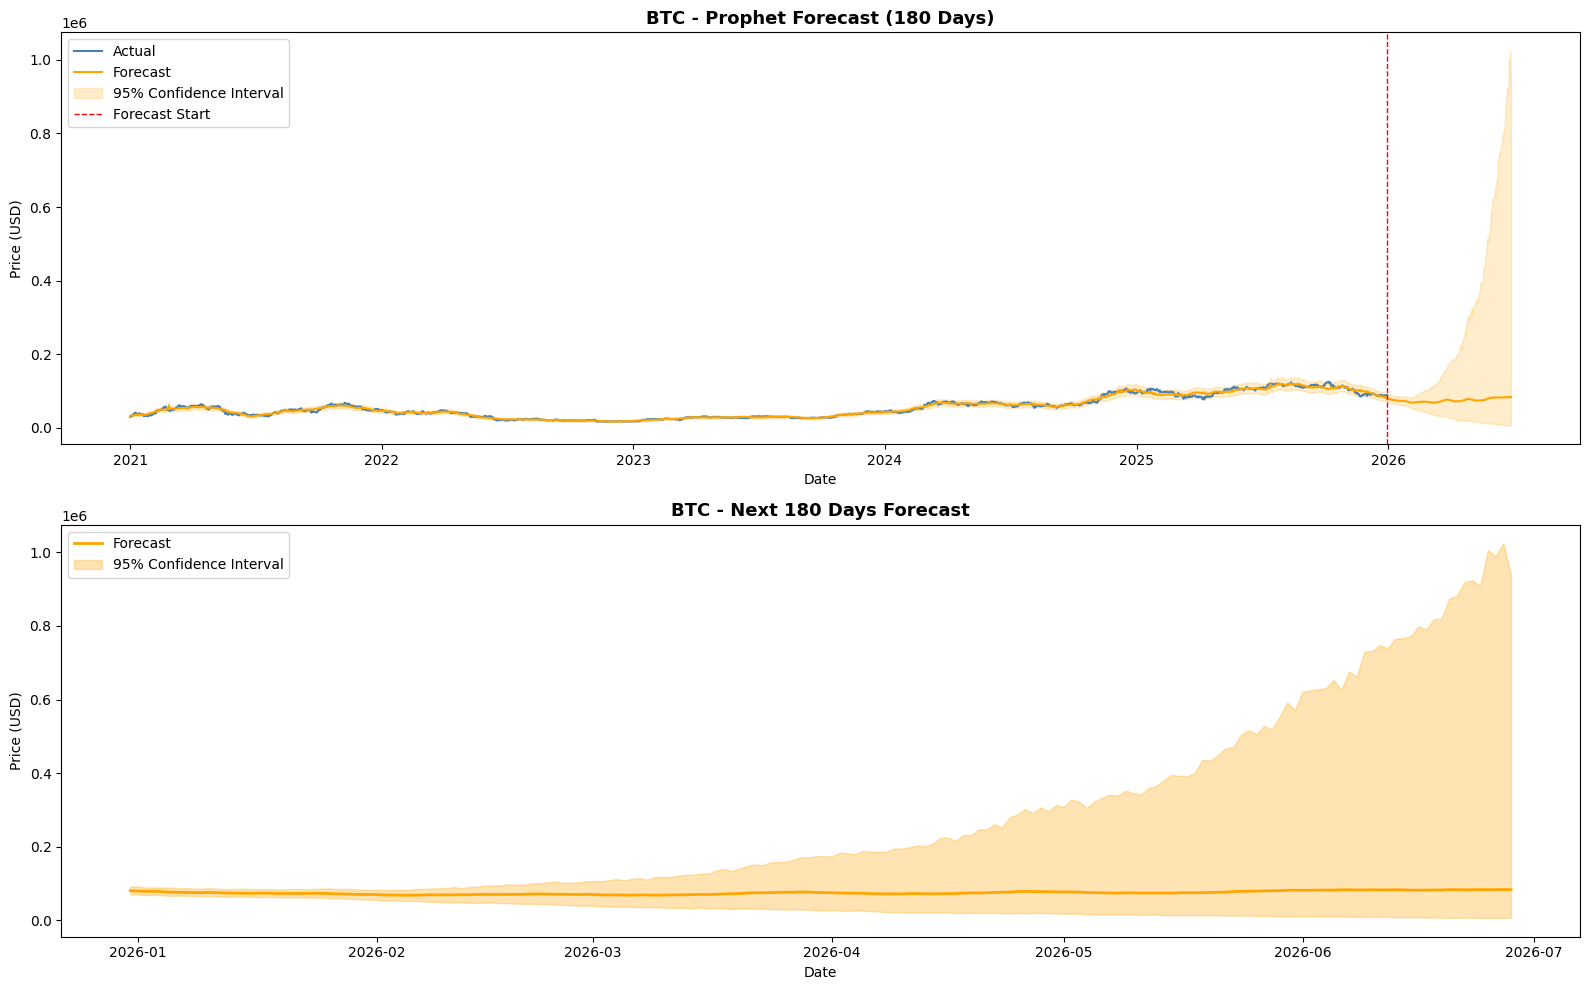

Saved: BTC_forecast.png


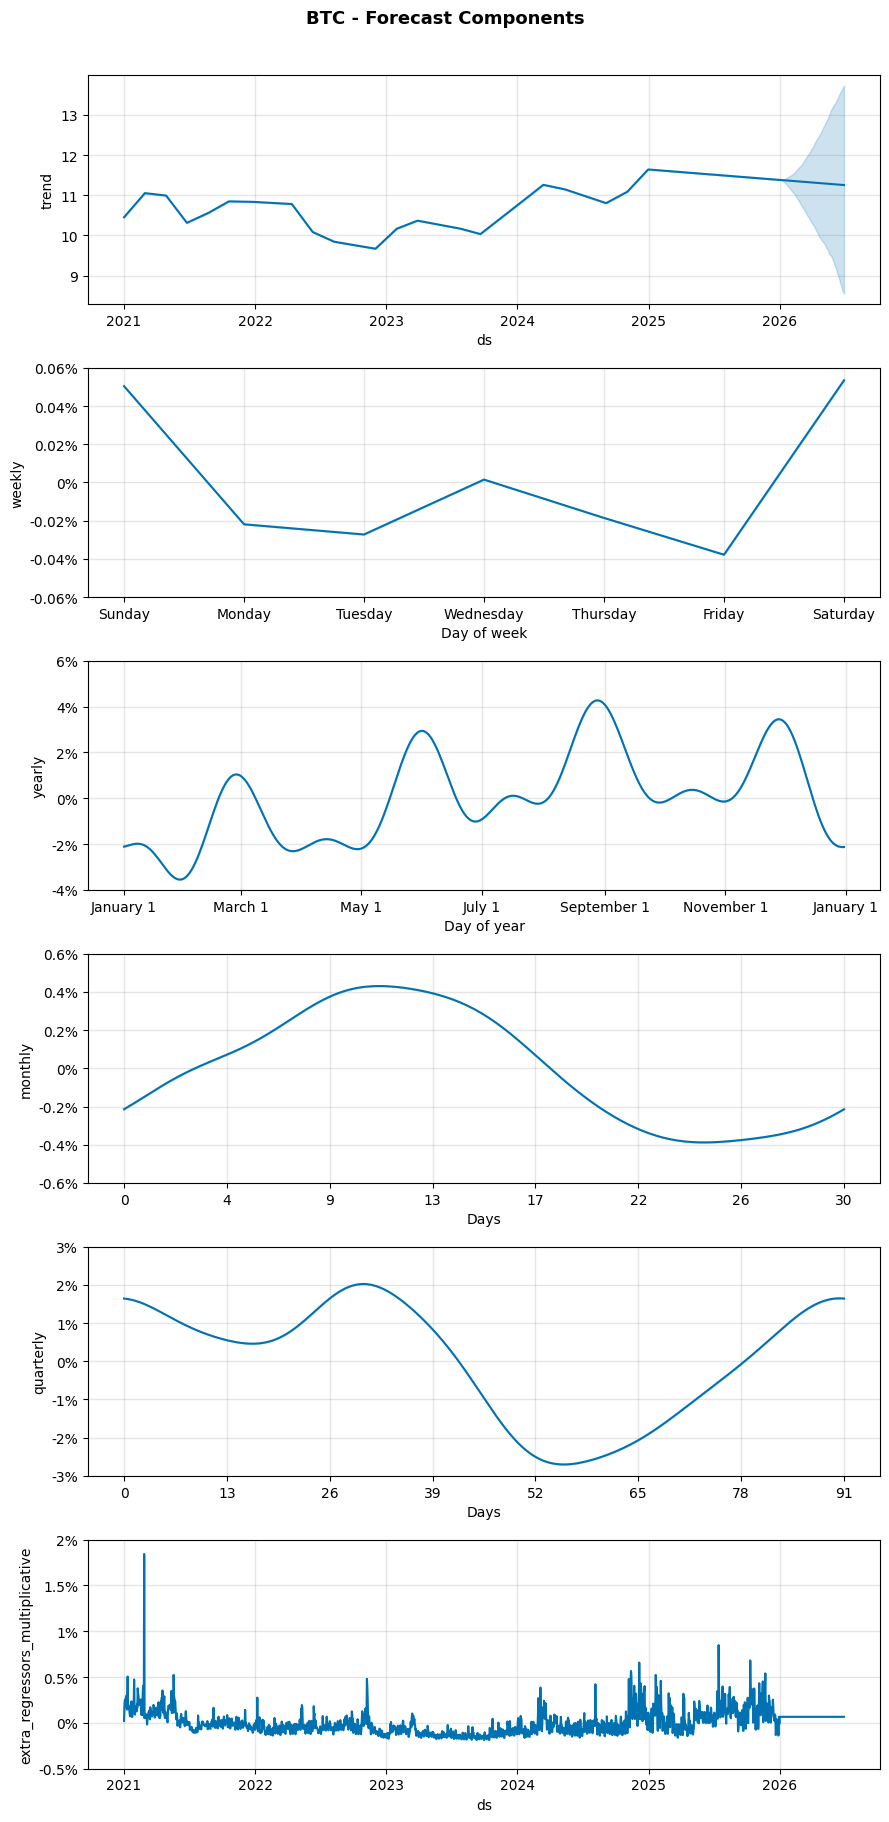

Saved: BTC_components.png

Training Prophet for: DOGE
----------------------------------------


15:33:59 - cmdstanpy - INFO - Chain [1] start processing
15:34:09 - cmdstanpy - INFO - Chain [1] done processing


MAE: 0.201  |  RMSE: 0.2219  |  MAPE: 135.4715%


15:34:10 - cmdstanpy - INFO - Chain [1] start processing
15:34:13 - cmdstanpy - INFO - Chain [1] done processing


Saved: DOGE_forecast.csv


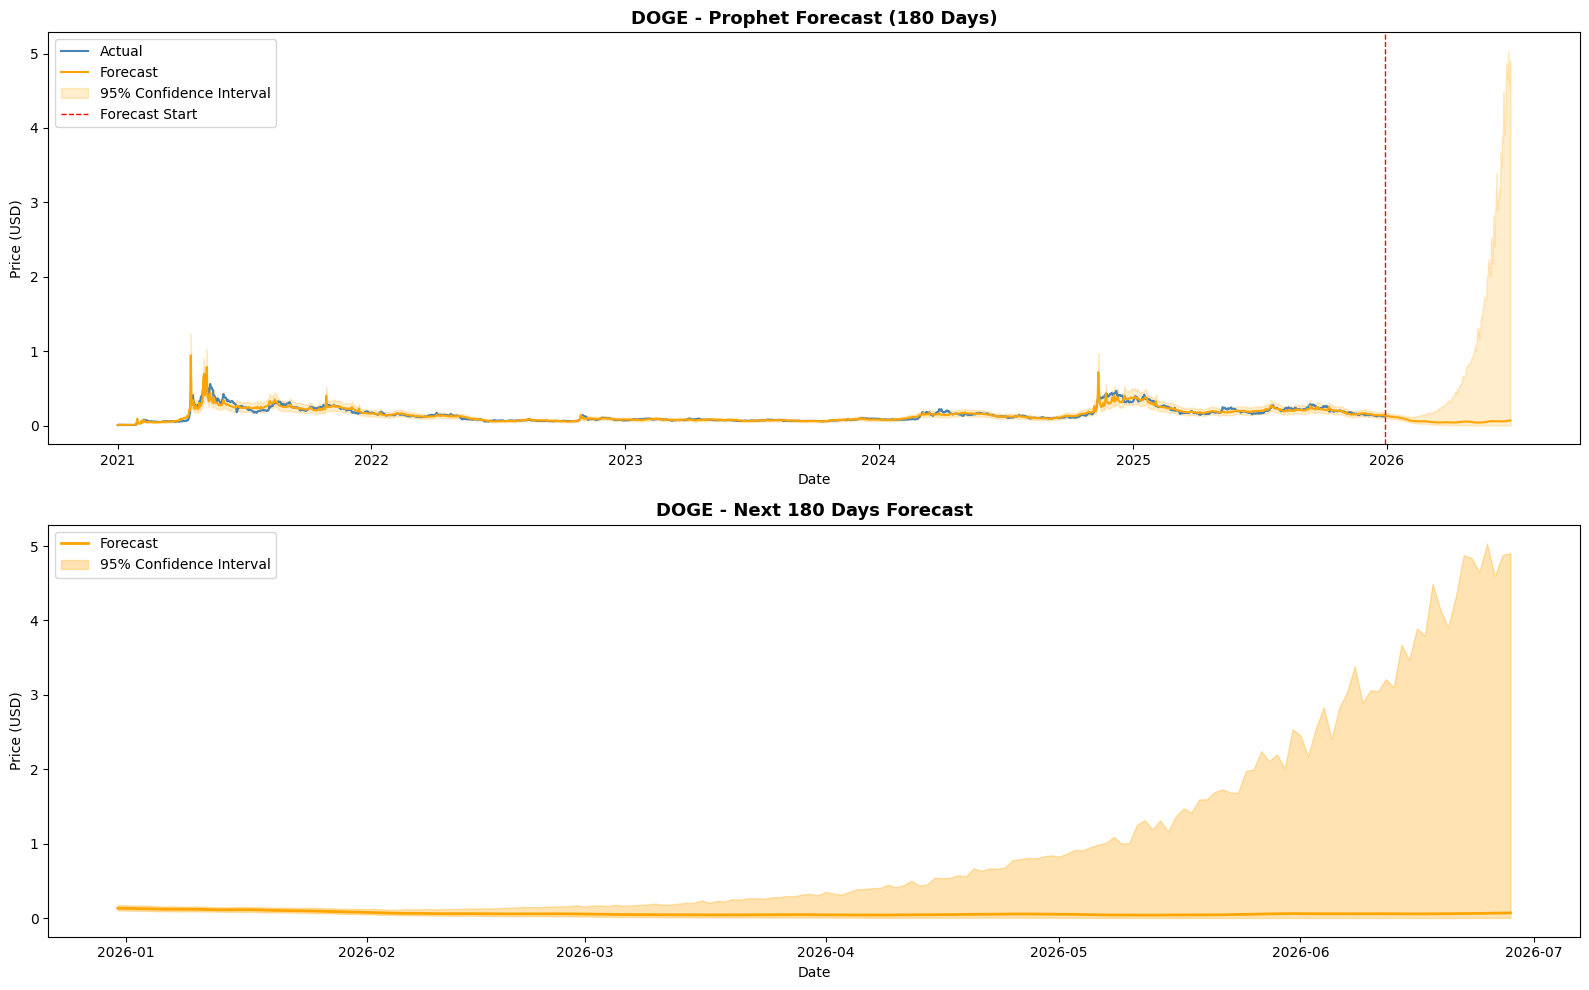

Saved: DOGE_forecast.png


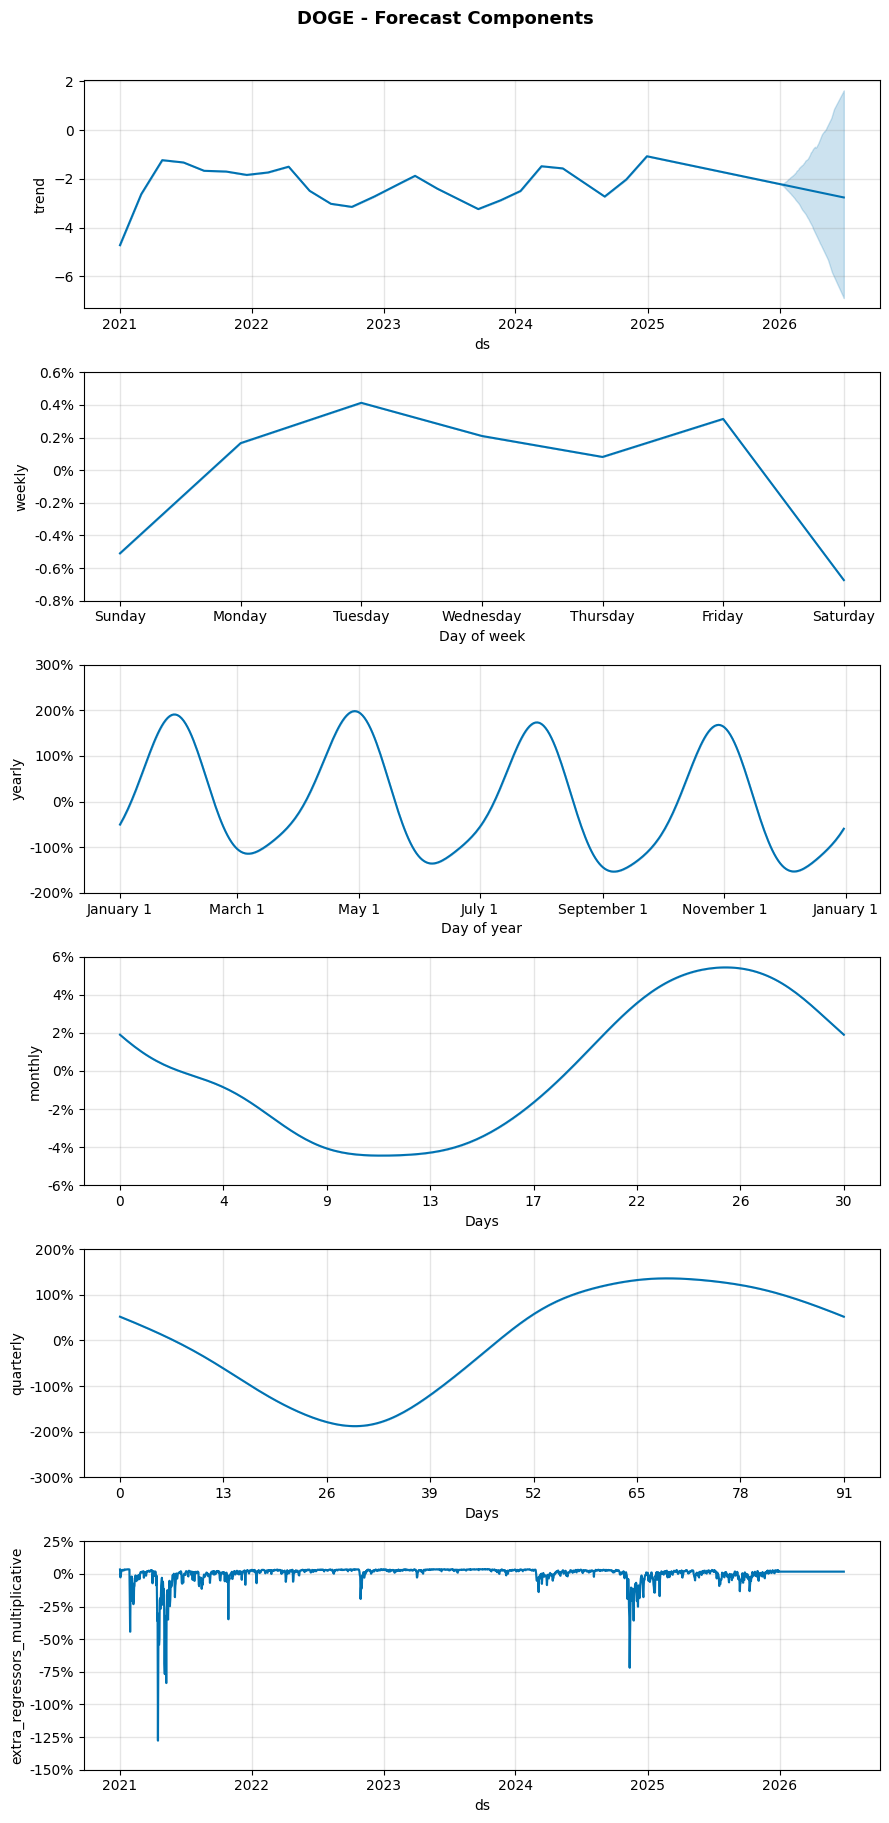

Saved: DOGE_components.png

Training Prophet for: DOT
----------------------------------------


15:34:26 - cmdstanpy - INFO - Chain [1] start processing
15:34:33 - cmdstanpy - INFO - Chain [1] done processing


MAE: 3.3646  |  RMSE: 3.7904  |  MAPE: 150.2505%


15:34:38 - cmdstanpy - INFO - Chain [1] start processing
15:34:43 - cmdstanpy - INFO - Chain [1] done processing


Saved: DOT_forecast.csv


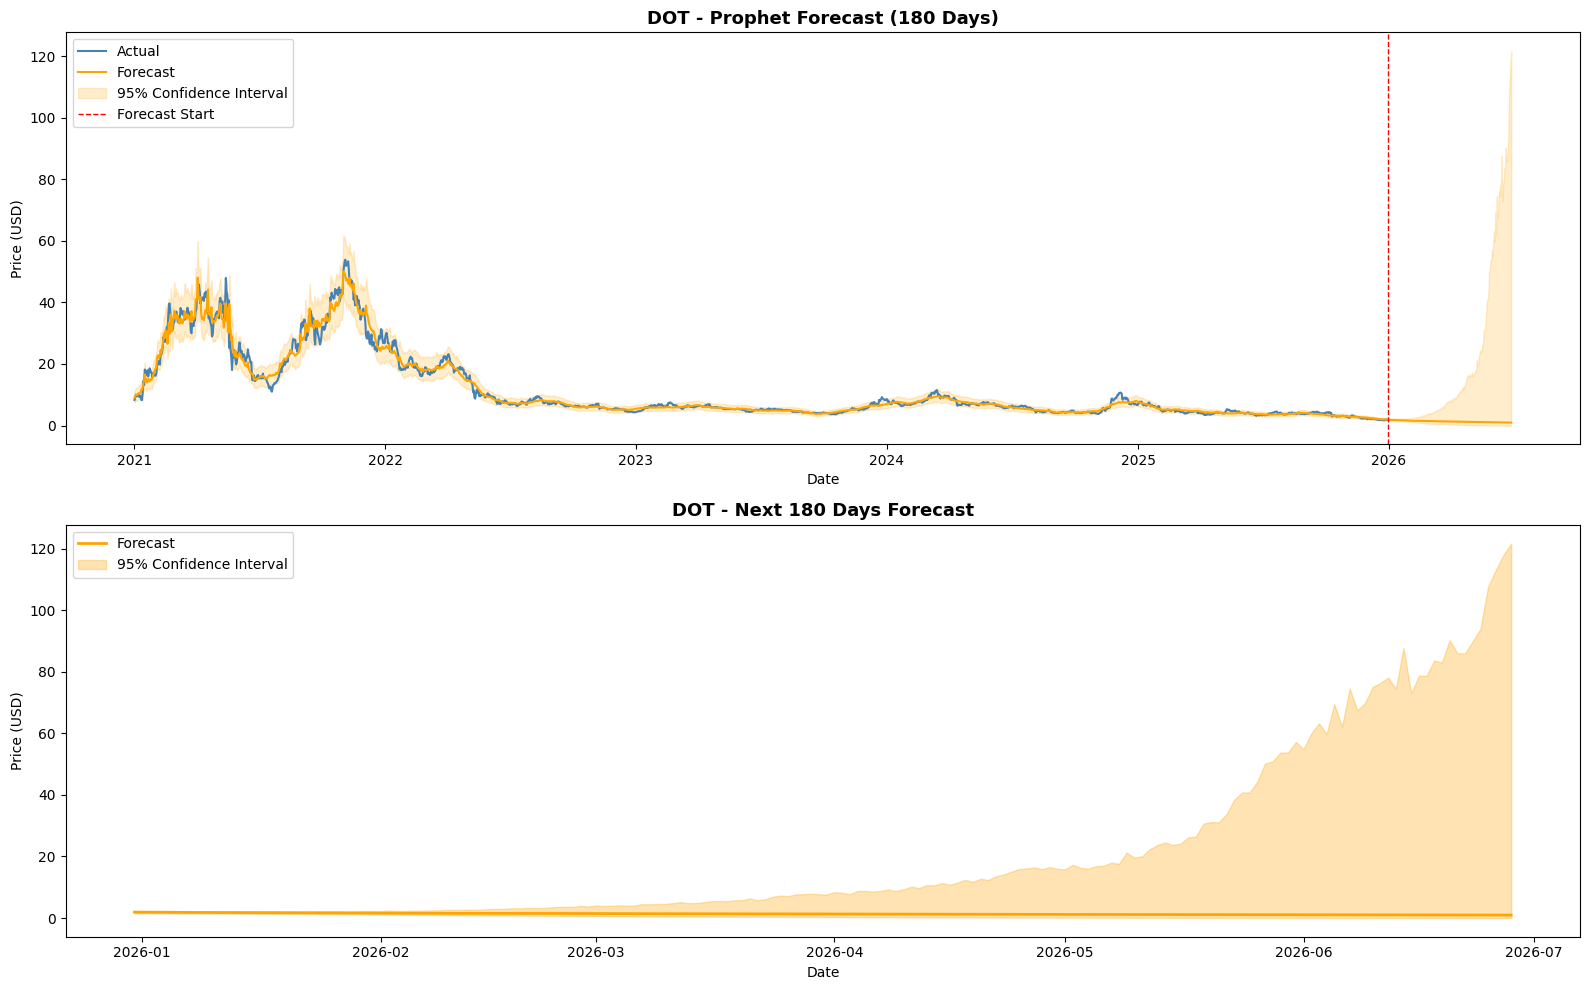

Saved: DOT_forecast.png


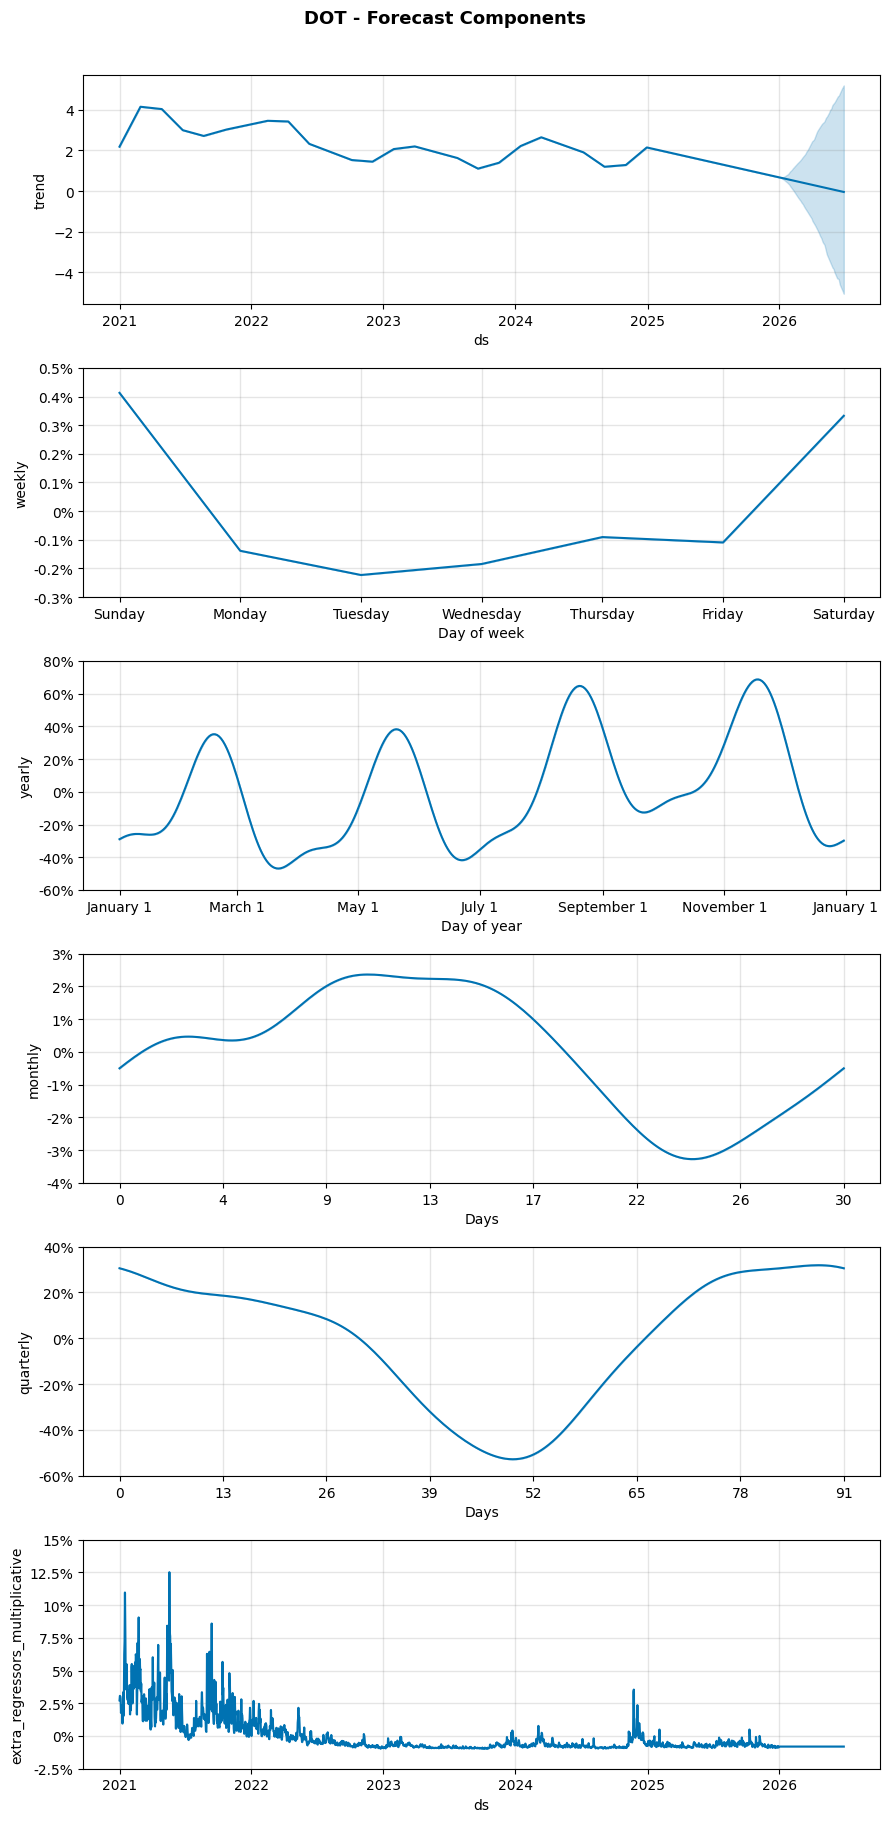

Saved: DOT_components.png

Training Prophet for: ETH
----------------------------------------


15:35:03 - cmdstanpy - INFO - Chain [1] start processing
15:35:09 - cmdstanpy - INFO - Chain [1] done processing


MAE: 1623.7599  |  RMSE: 1825.9073  |  MAPE: 51.6%


15:35:10 - cmdstanpy - INFO - Chain [1] start processing
15:35:12 - cmdstanpy - INFO - Chain [1] done processing


Saved: ETH_forecast.csv


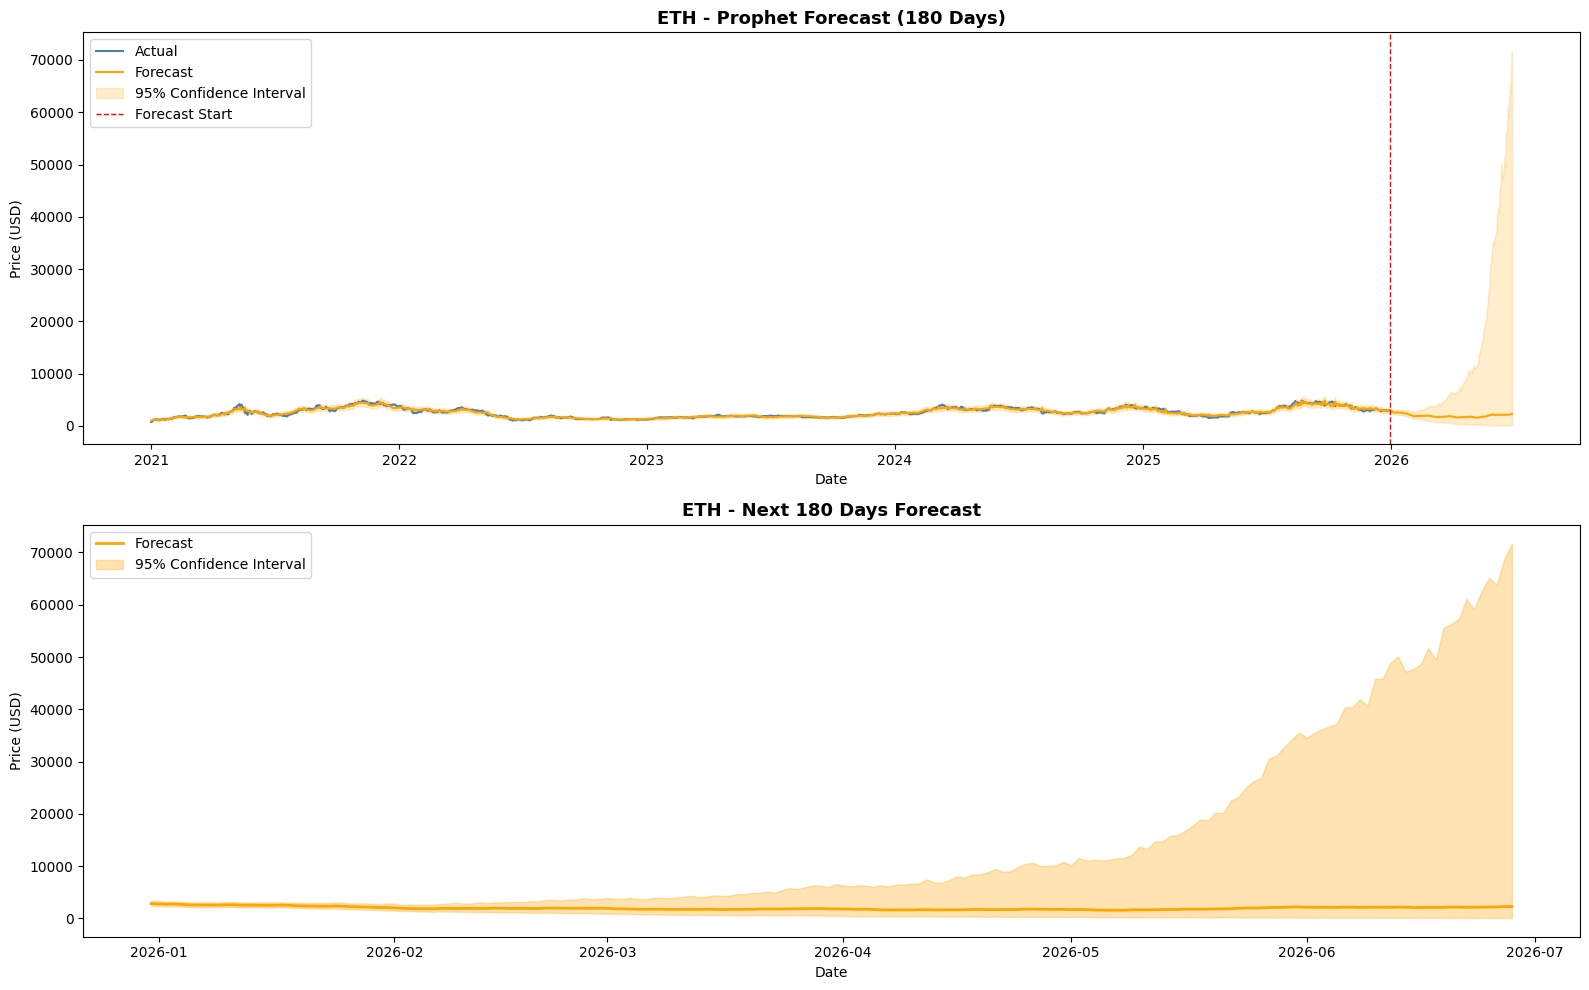

Saved: ETH_forecast.png


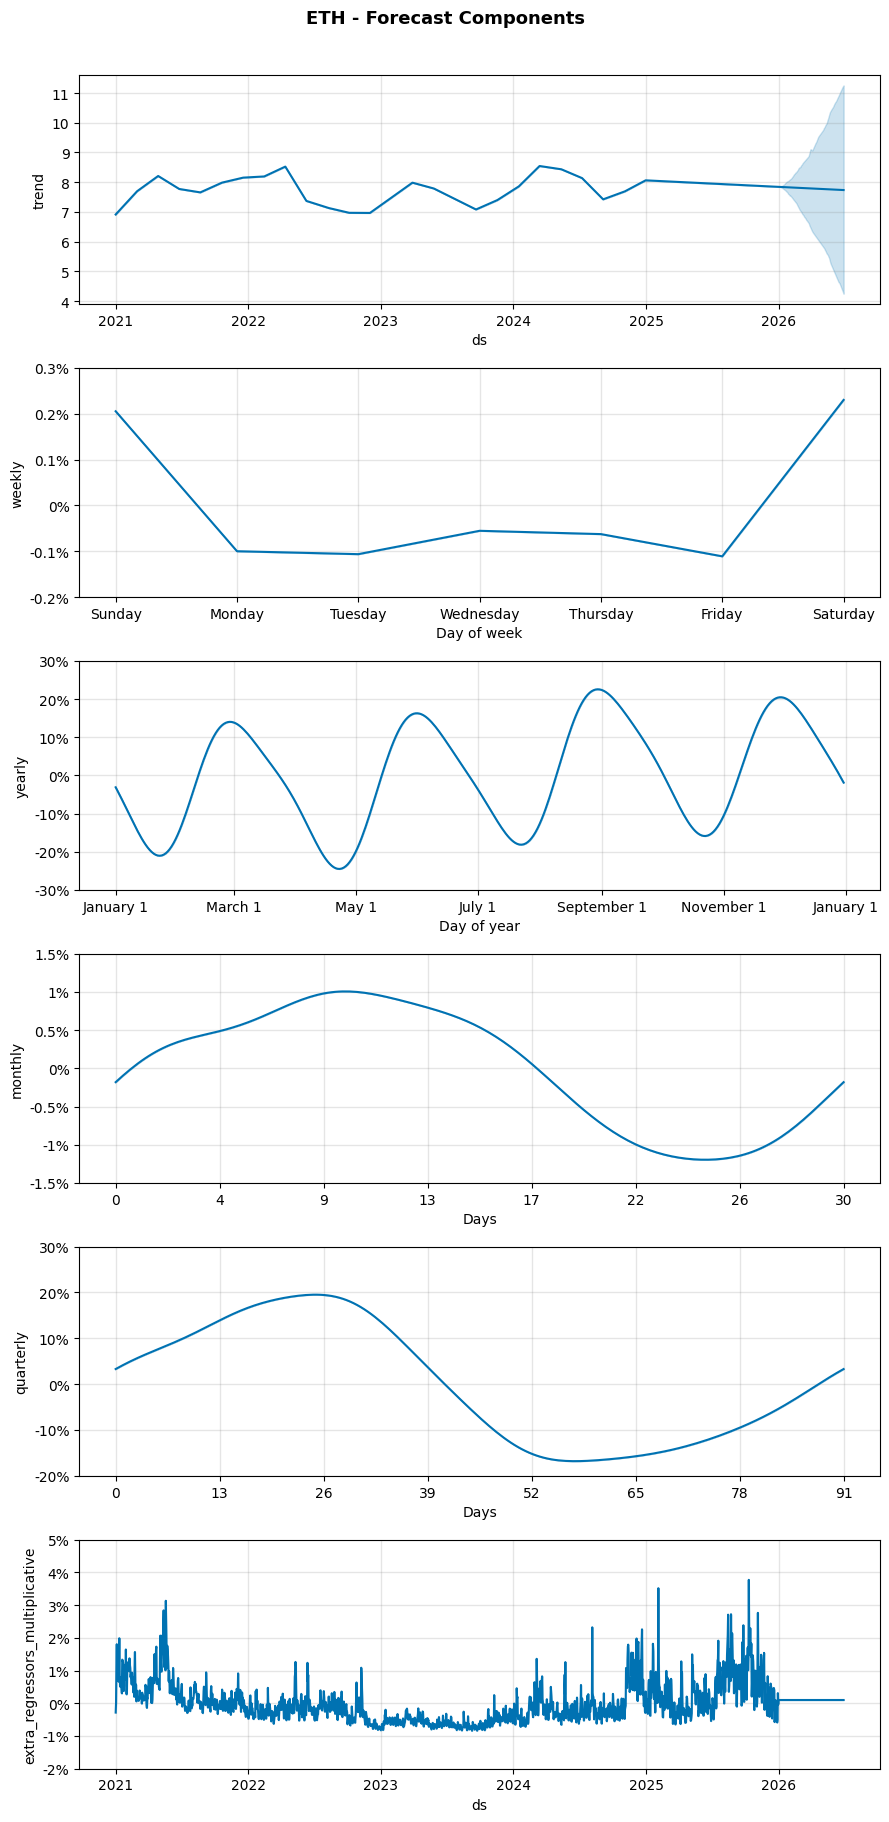

Saved: ETH_components.png

Training Prophet for: LINK
----------------------------------------


15:35:24 - cmdstanpy - INFO - Chain [1] start processing
15:35:27 - cmdstanpy - INFO - Chain [1] done processing


MAE: 37.6452  |  RMSE: 42.1908  |  MAPE: 272.8172%


15:35:29 - cmdstanpy - INFO - Chain [1] start processing
15:35:31 - cmdstanpy - INFO - Chain [1] done processing


Saved: LINK_forecast.csv


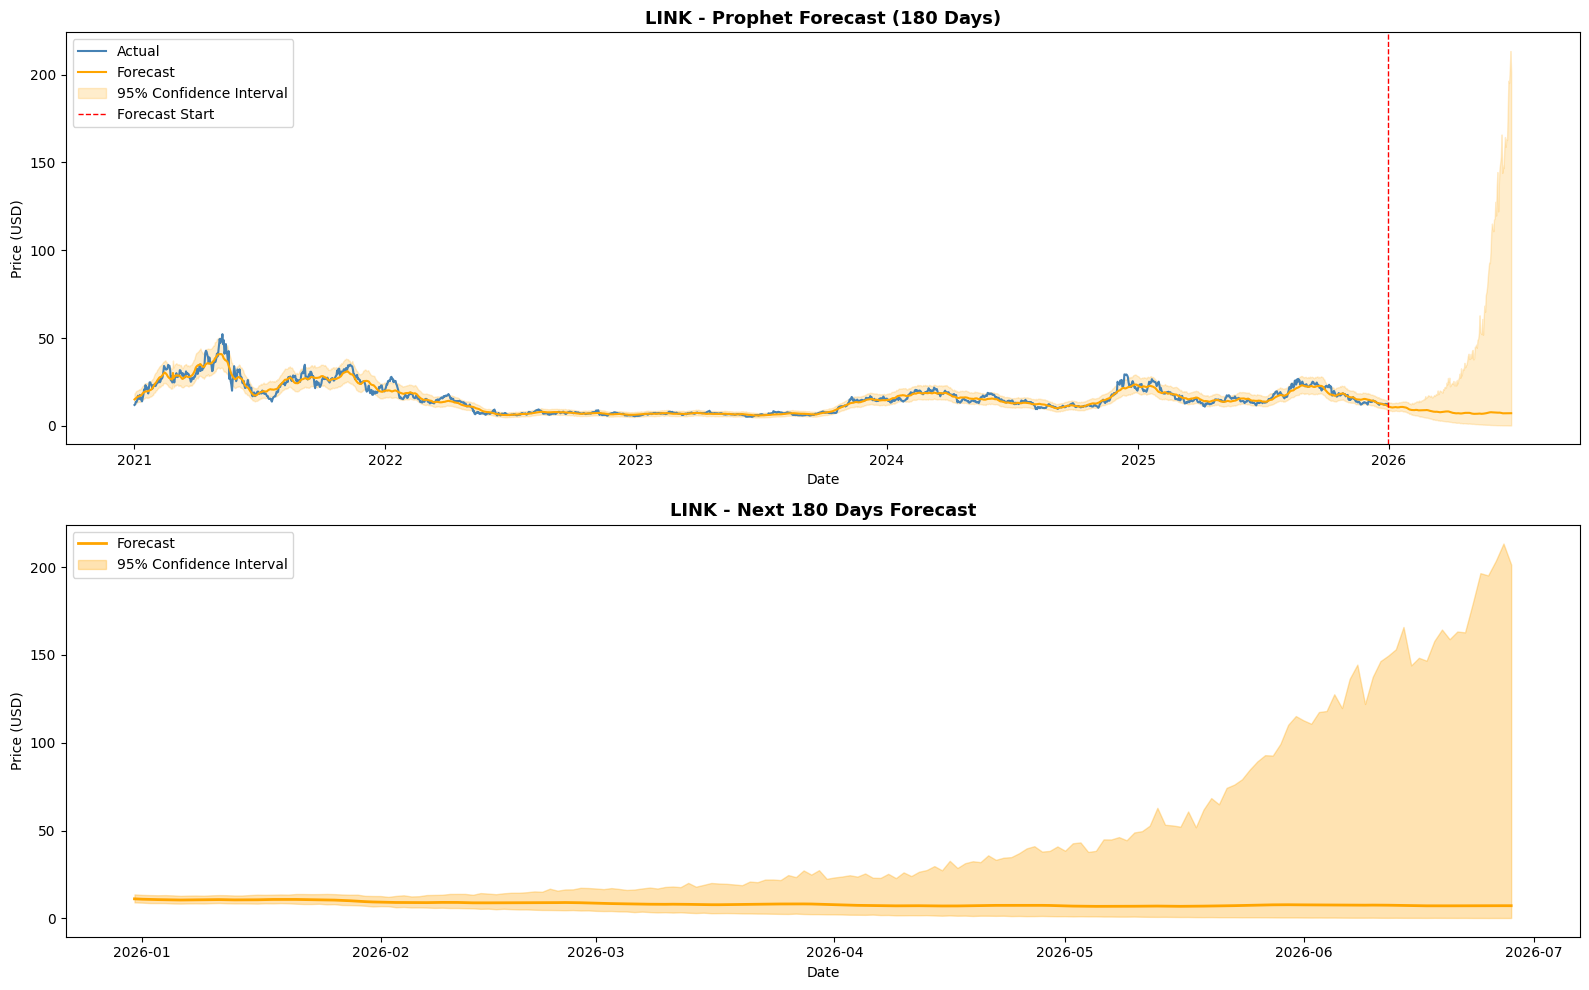

Saved: LINK_forecast.png


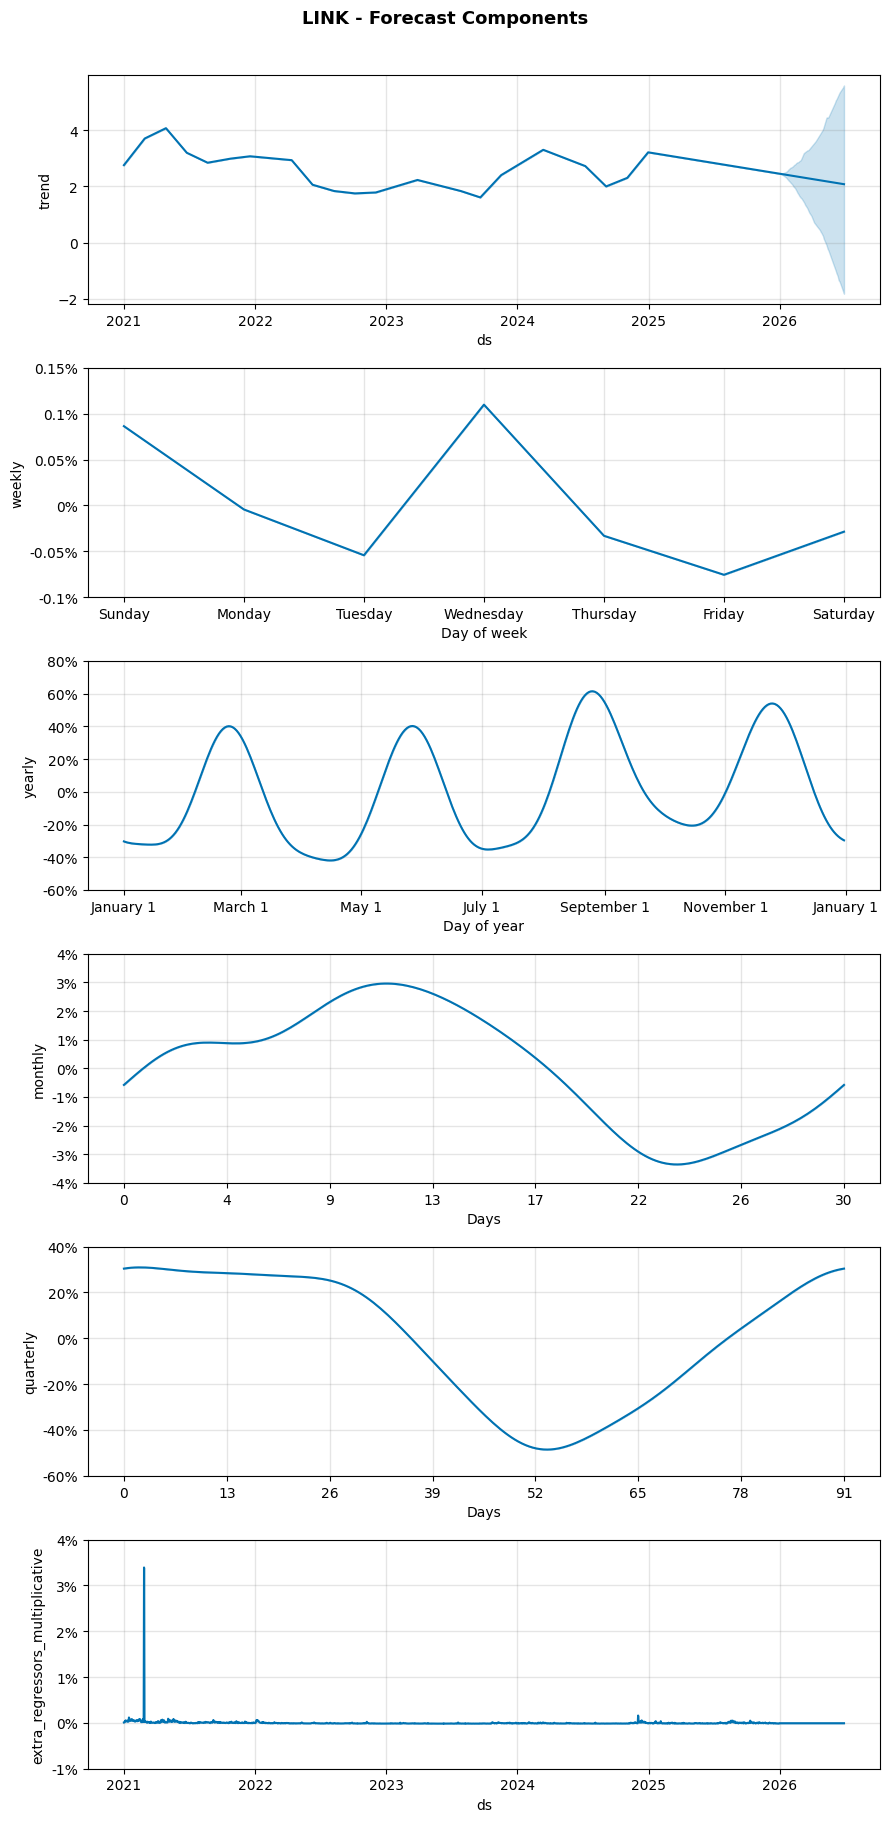

Saved: LINK_components.png

Training Prophet for: LTC
----------------------------------------


15:35:47 - cmdstanpy - INFO - Chain [1] start processing
15:35:59 - cmdstanpy - INFO - Chain [1] done processing


MAE: 85.5296  |  RMSE: 95.3144  |  MAPE: 100.3584%


15:36:02 - cmdstanpy - INFO - Chain [1] start processing
15:36:07 - cmdstanpy - INFO - Chain [1] done processing


Saved: LTC_forecast.csv


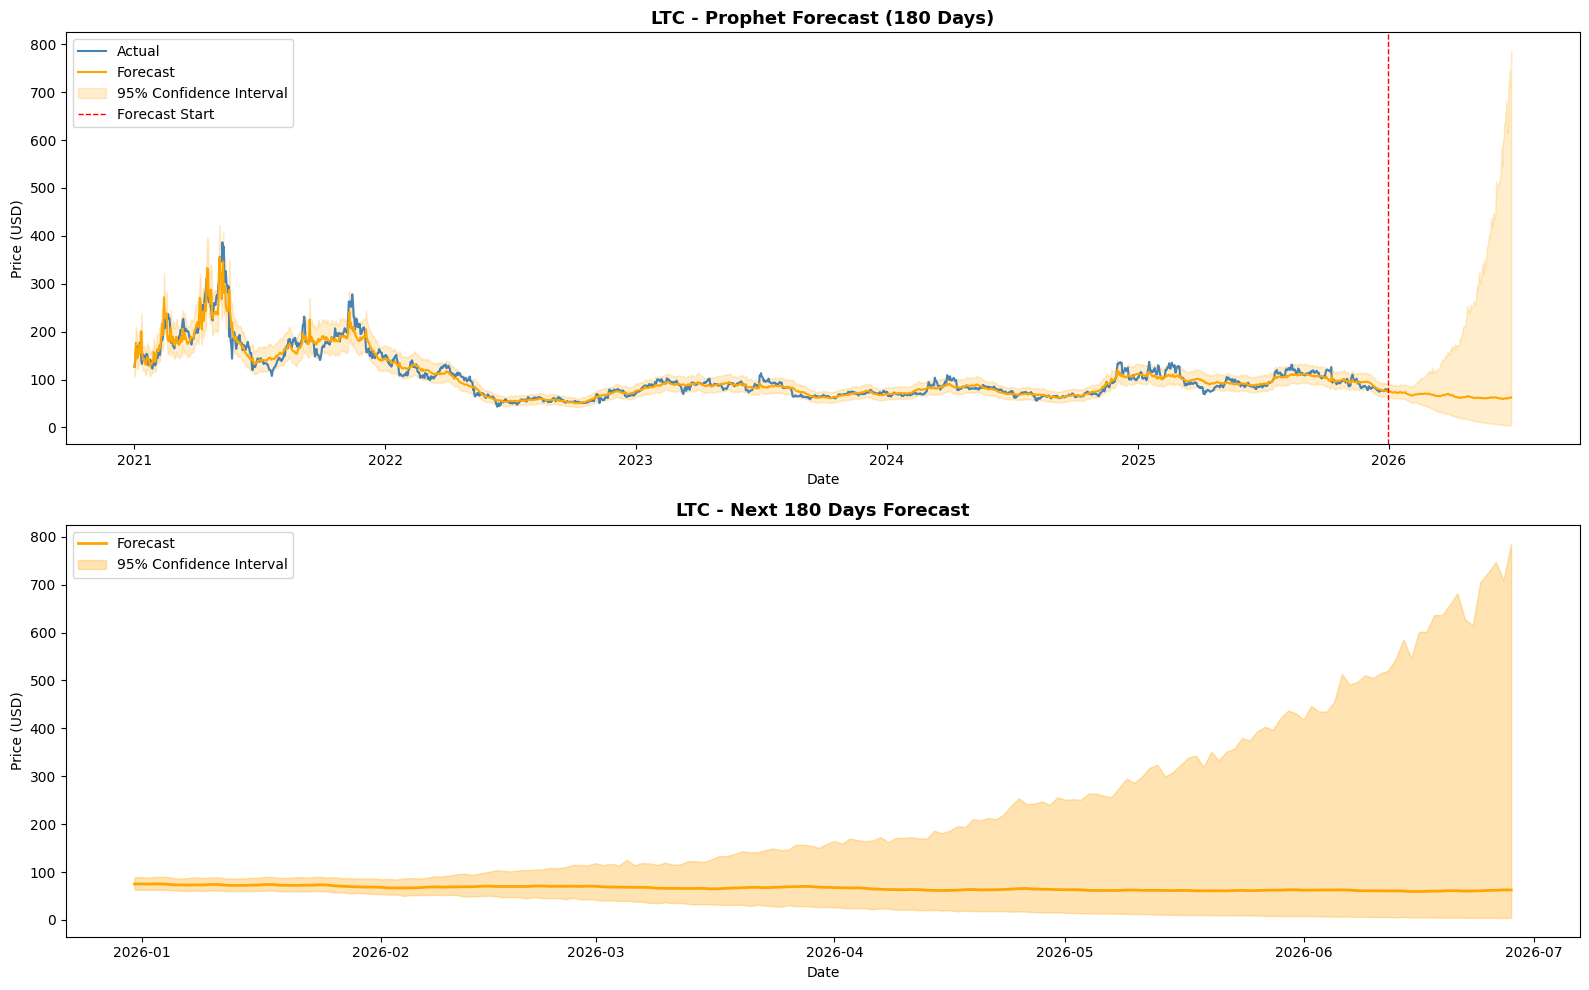

Saved: LTC_forecast.png


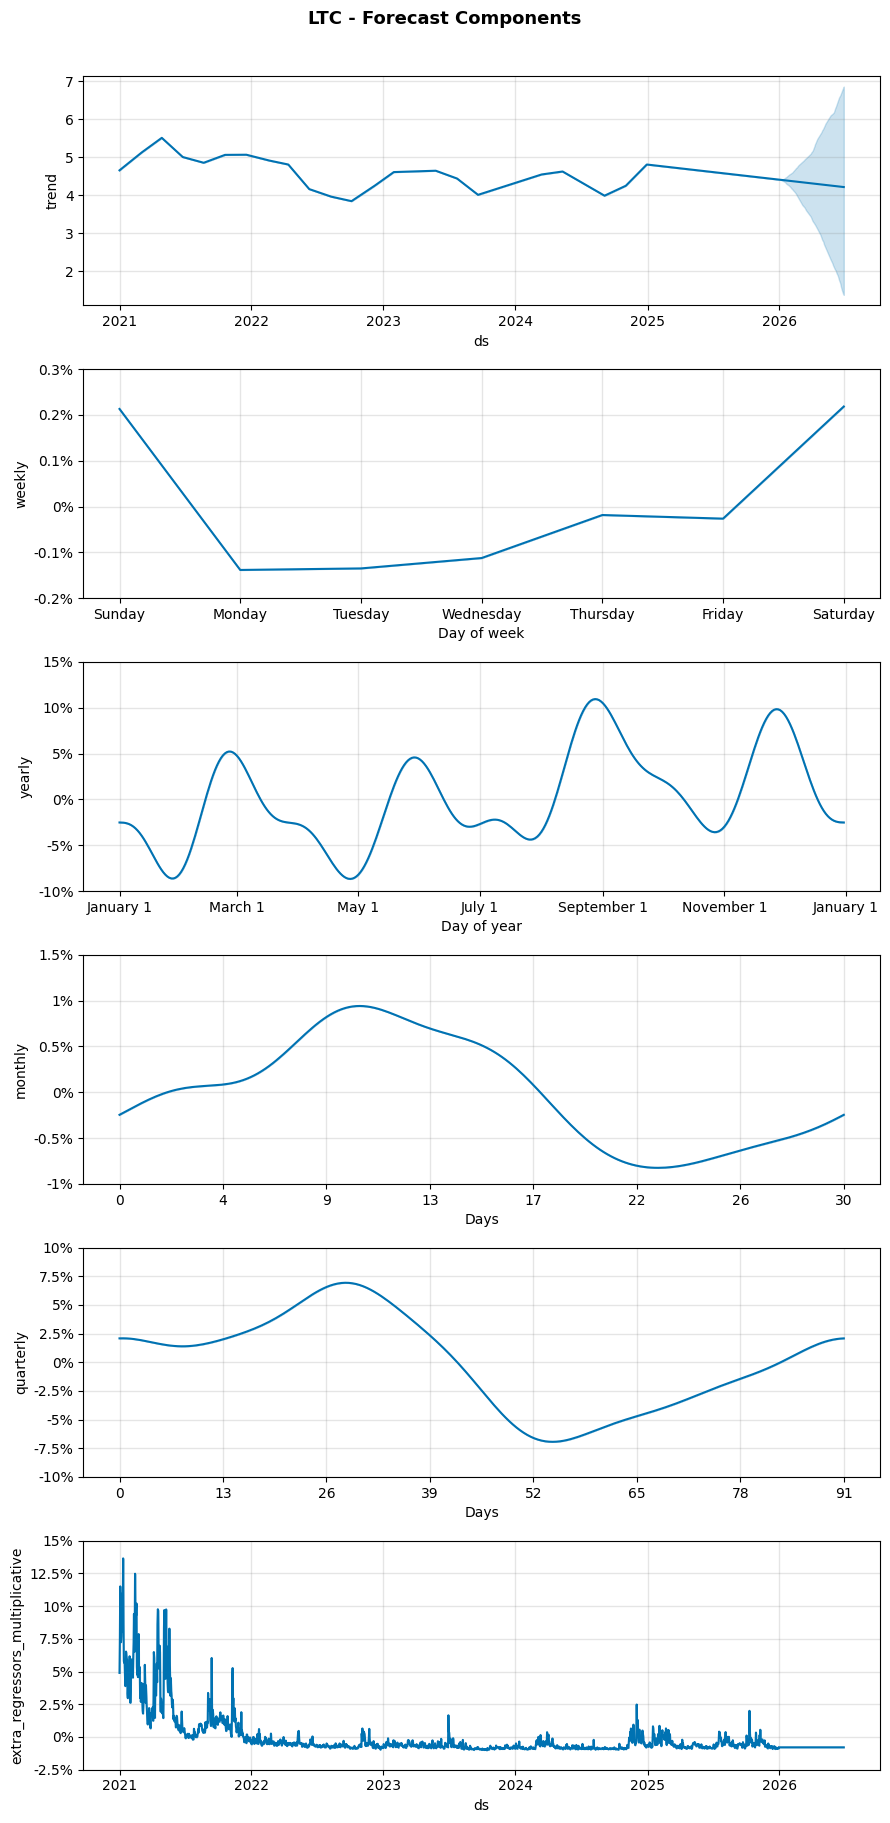

Saved: LTC_components.png

Training Prophet for: SOL
----------------------------------------


15:36:24 - cmdstanpy - INFO - Chain [1] start processing
15:36:27 - cmdstanpy - INFO - Chain [1] done processing


MAE: 138.7005  |  RMSE: 150.6752  |  MAPE: 97.5143%


15:36:30 - cmdstanpy - INFO - Chain [1] start processing
15:36:32 - cmdstanpy - INFO - Chain [1] done processing


Saved: SOL_forecast.csv


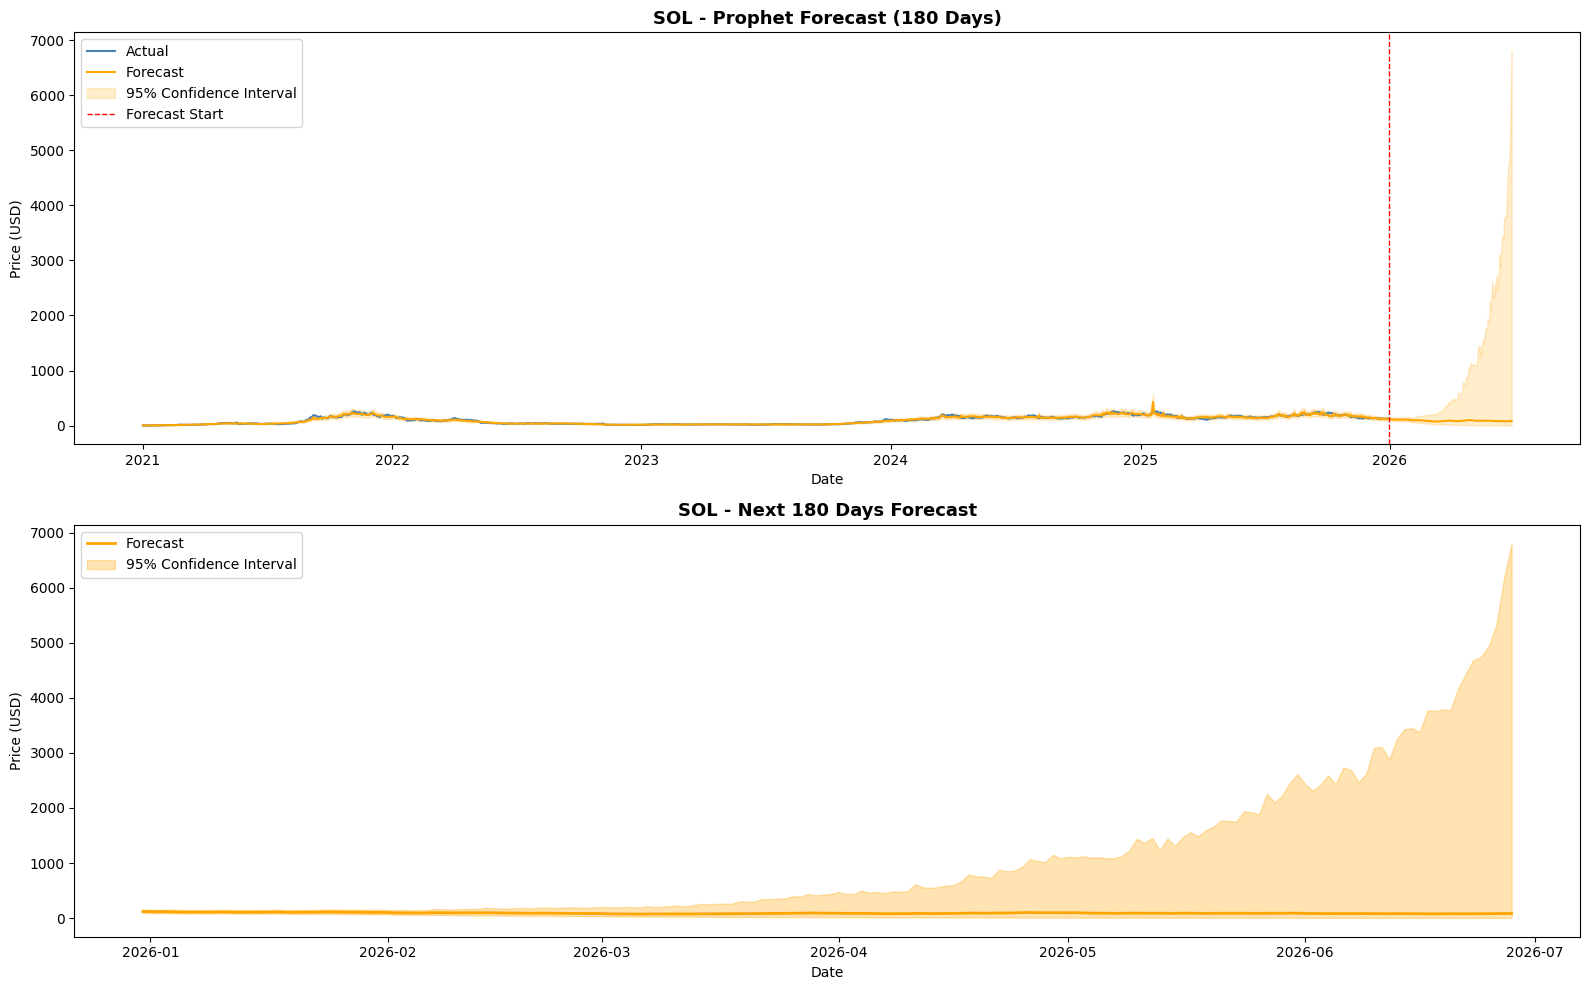

Saved: SOL_forecast.png


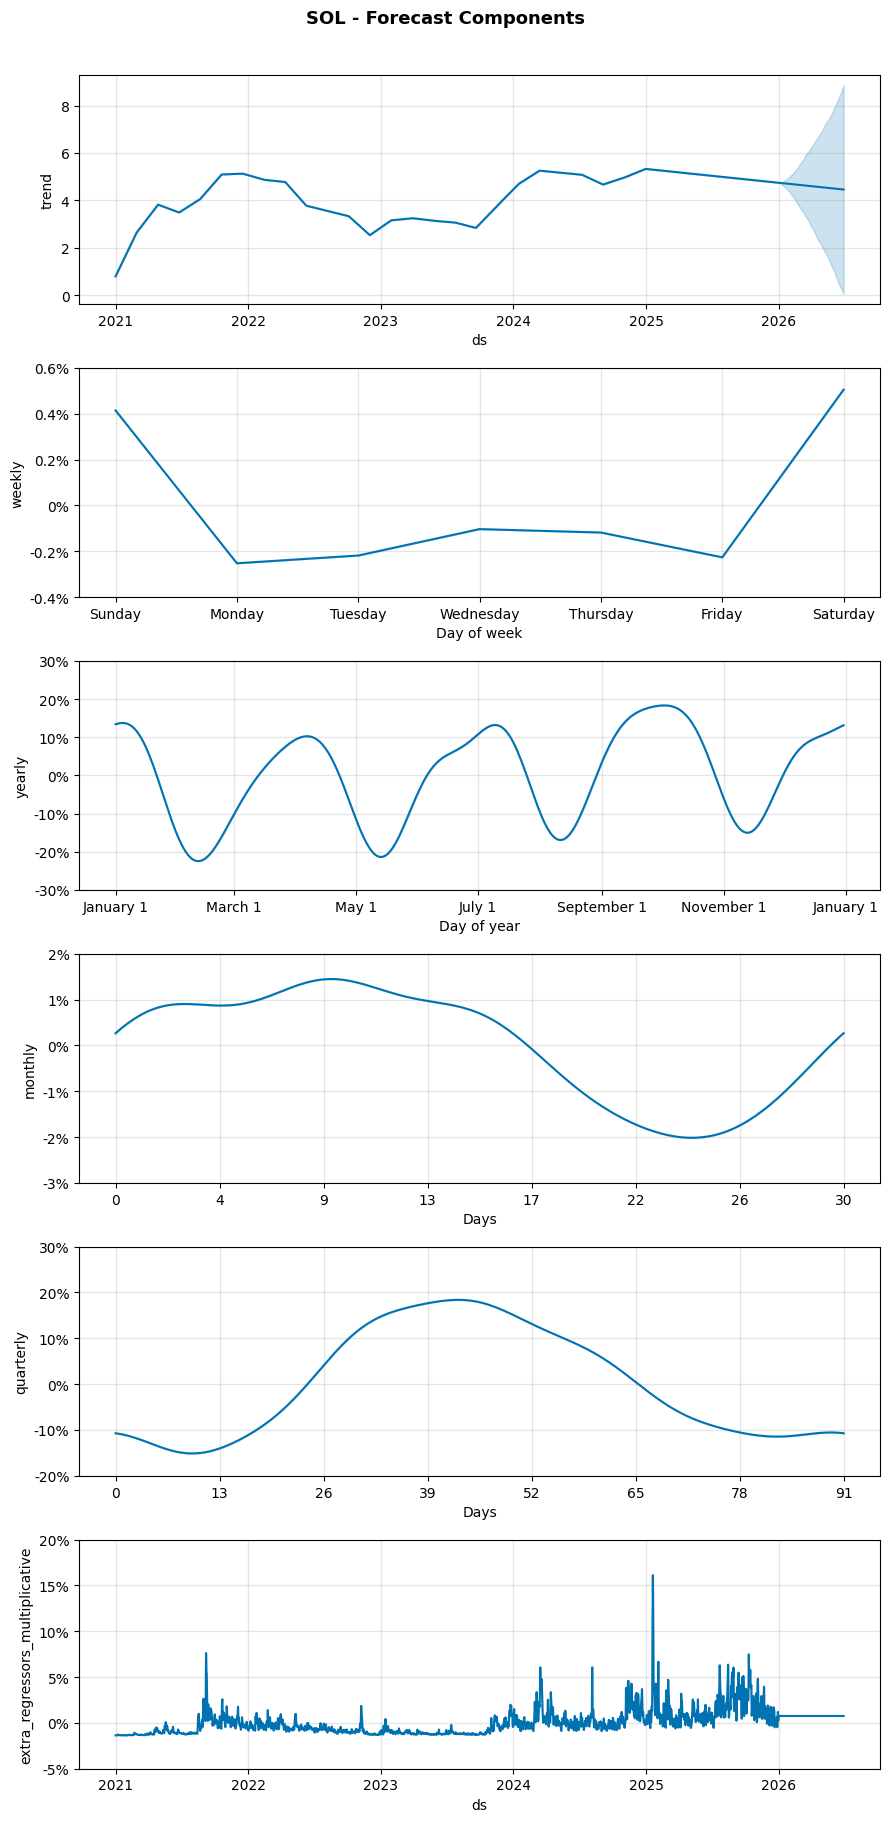

Saved: SOL_components.png

Training Prophet for: XRP
----------------------------------------


15:36:46 - cmdstanpy - INFO - Chain [1] start processing
15:36:51 - cmdstanpy - INFO - Chain [1] done processing


MAE: 53.1067  |  RMSE: 82.3289  |  MAPE: 2673.1233%


15:36:53 - cmdstanpy - INFO - Chain [1] start processing
15:36:56 - cmdstanpy - INFO - Chain [1] done processing


Saved: XRP_forecast.csv


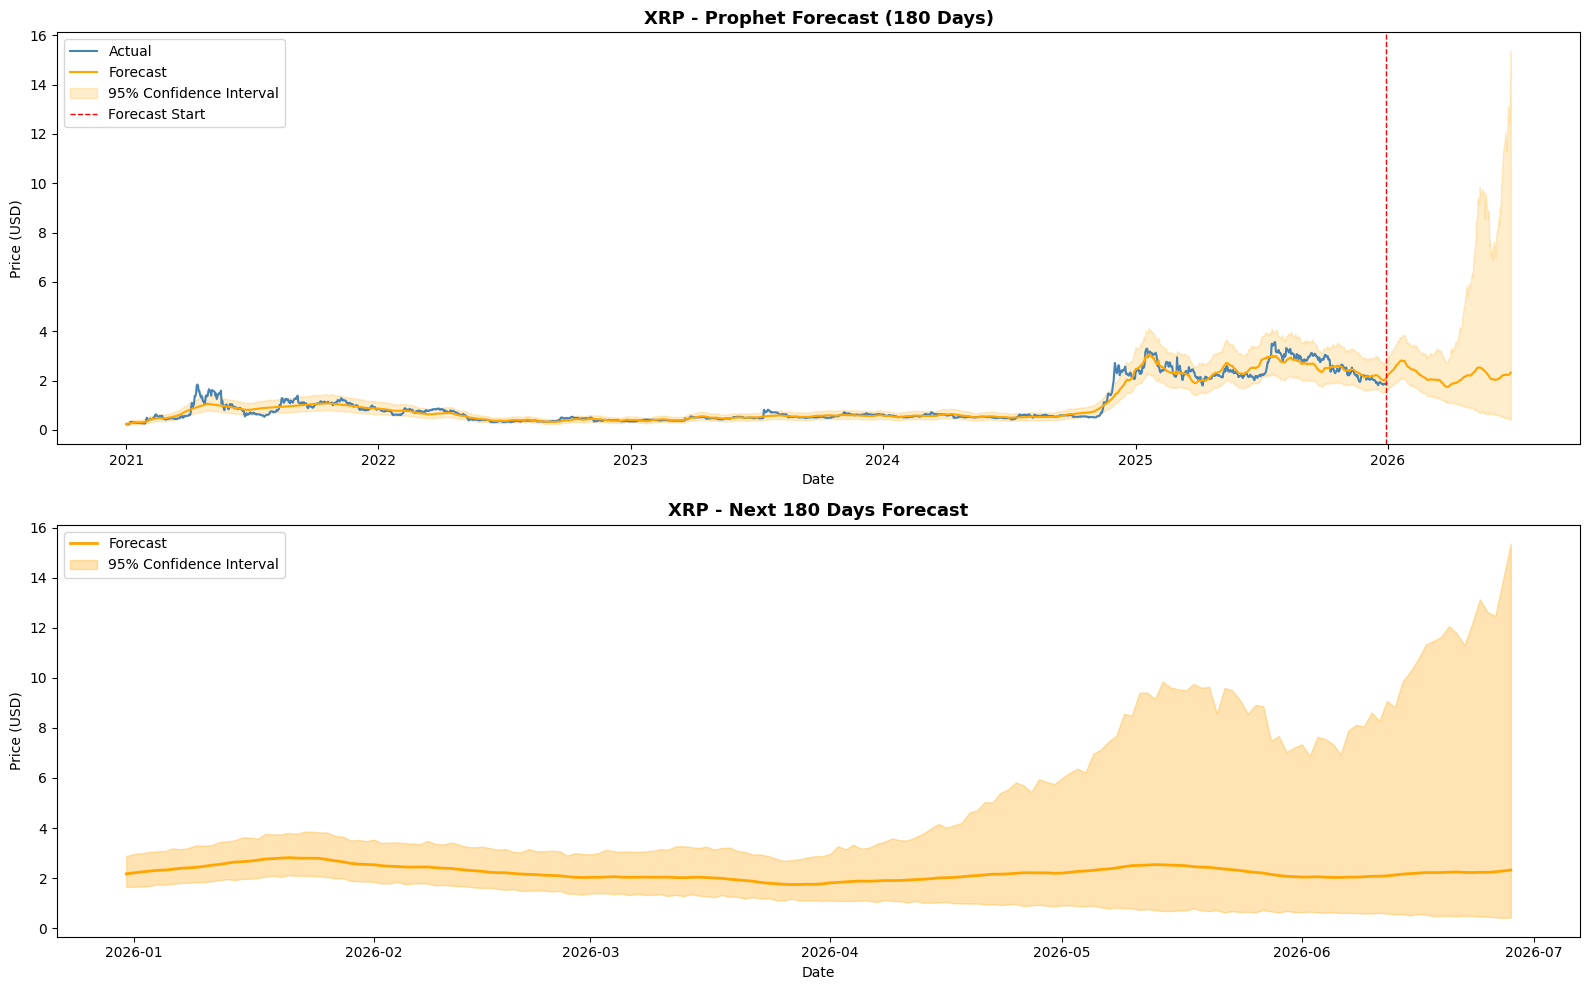

Saved: XRP_forecast.png


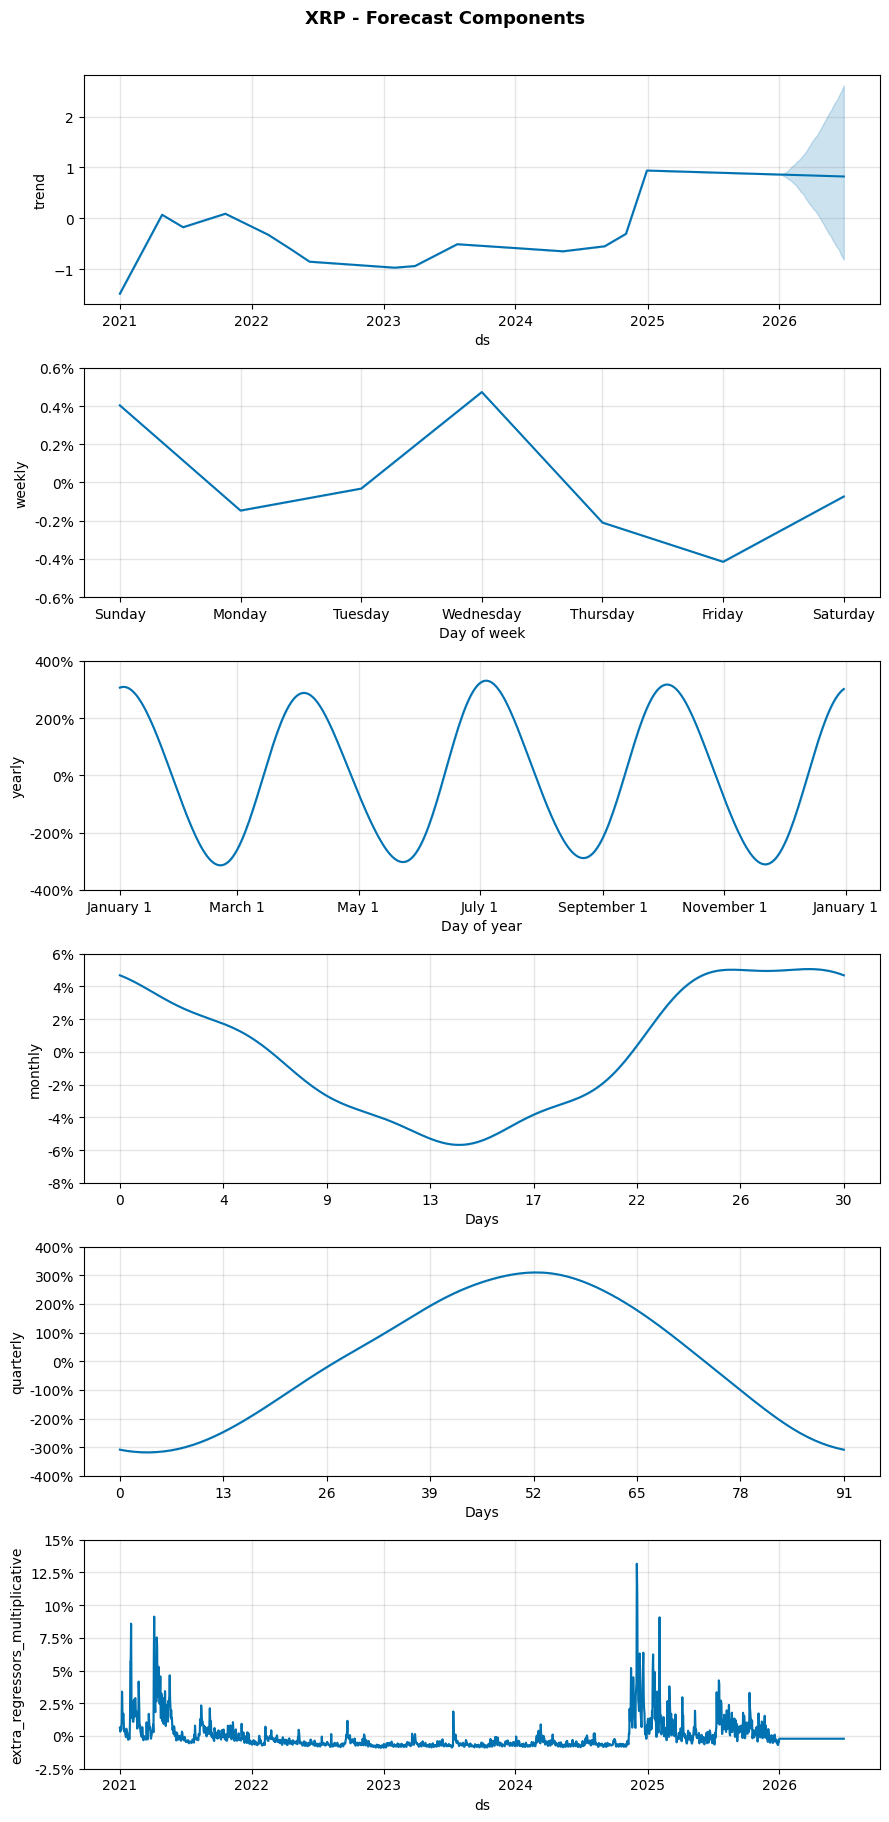

Saved: XRP_components.png

All Prophet models trained successfully.


In [ ]:
FORECAST_DAYS = 180
output_dir    = "../data/forecasts/prophet"
all_metrics   = []
all_forecasts = []

cryptos = df["Crypto"].unique()

for crypto in cryptos:
    print(f"\nTraining Prophet for: {crypto}")
    print("-" * 40)

    prophet_df = prepare_prophet_data(df, crypto)

    # Train / test split (last 90 days as test)
    train_df = prophet_df[:-90].copy()
    test_df  = prophet_df[-90:].copy()

    # --- Train on train set ---
    model = build_prophet_model(crypto)
    model.fit(train_df)

    # Predict on test period
    test_future              = model.make_future_dataframe(periods=90)
    test_future              = test_future.merge(
        prophet_df[["ds", "volume_scaled"]], on="ds", how="left"
    )
    test_future["volume_scaled"] = test_future["volume_scaled"].fillna(0)
    test_forecast            = model.predict(test_future)
    test_pred                = test_forecast[
        test_forecast["ds"].isin(test_df["ds"])
    ]["yhat"].values

    # Evaluate on original price scale
    metrics          = evaluate_model(test_df["y"].values, test_pred)
    metrics["Crypto"] = crypto
    all_metrics.append(metrics)
    print(f"MAE: {metrics['MAE']}  |  RMSE: {metrics['RMSE']}  |  MAPE: {metrics['MAPE']}%")

    # --- Retrain on full data ---
    full_model = build_prophet_model(crypto)
    full_model.fit(prophet_df)

    # Build future dataframe with volume regressor
    future                   = full_model.make_future_dataframe(periods=FORECAST_DAYS)
    future                   = future.merge(
        prophet_df[["ds", "volume_scaled"]], on="ds", how="left"
    )
    # Fill future volume with rolling mean of last 30 days
    last_vol                 = prophet_df["volume_scaled"].tail(30).mean()
    future["volume_scaled"]  = future["volume_scaled"].fillna(last_vol)

    forecast = full_model.predict(future)

    # Save forecast CSV (convert back from log)
    forecast_out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
    forecast_out["yhat"]       = np.exp(forecast_out["yhat"])
    forecast_out["yhat_lower"] = np.exp(forecast_out["yhat_lower"])
    forecast_out["yhat_upper"] = np.exp(forecast_out["yhat_upper"])
    forecast_out.columns       = ["Date", "Forecast", "Lower_Bound", "Upper_Bound"]
    forecast_out["Crypto"]     = crypto
    forecast_out.to_csv(f"{output_dir}/{crypto}_forecast.csv", index=False)
    print(f"Saved: {crypto}_forecast.csv")

    all_forecasts.append(forecast_out)

    # Plots
    plot_forecast(crypto, prophet_df, forecast, output_dir)
    plot_components(crypto, full_model, forecast, output_dir)

print("\nAll Prophet models trained successfully.")

## Cross Validation — BTC
Cross validation provides a more robust estimate of forecast accuracy
by simulating multiple historical forecasts at different cutoff points.

**Configuration:**
| Parameter | Value | Meaning |
|-----------|-------|---------|
| initial | 730 days | Minimum training data (2 years) |
| period | 90 days | New cutoff every 90 days |
| horizon | 180 days | Evaluate up to 180 days ahead |

This generates multiple train/test windows and averages the error
metrics across all windows — giving a more reliable performance estimate.

In [ ]:
print("Running cross validation on BTC...")

btc_df    = prepare_prophet_data(df, "BTC")
btc_model = build_prophet_model("BTC")
btc_model.fit(btc_df)

cv_results = cross_validation(
    btc_model,
    initial="730 days",
    period="90 days",
    horizon="180 days",
    parallel="processes"
)

cv_metrics = performance_metrics(cv_results)
print(cv_metrics[["horizon", "mae", "rmse", "mape"]].head(10))

cv_metrics.to_csv(f"{output_dir}/BTC_cross_validation.csv", index=False)
print("Saved: BTC_cross_validation.csv")

Running cross validation on BTC...


15:37:11 - cmdstanpy - INFO - Chain [1] start processing
15:37:21 - cmdstanpy - INFO - Chain [1] done processing


  horizon       mae      rmse      mape
0 18 days  0.128349  0.175056  0.012168
1 19 days  0.134907  0.182665  0.012788
2 20 days  0.140437  0.189908  0.013308
3 21 days  0.146703  0.197246  0.013892
4 22 days  0.152219  0.203981  0.014401
5 23 days  0.157066  0.210096  0.014850
6 24 days  0.161315  0.215656  0.015238
7 25 days  0.166187  0.221229  0.015682
8 26 days  0.170523  0.226489  0.016075
9 27 days  0.175443  0.232477  0.016524
Saved: BTC_cross_validation.csv


## Save Combined Forecast
Concatenate all 10 cryptocurrency forecasts into a single CSV file
for use in the Power BI dashboard and model comparison notebook.

In [ ]:
combined_forecast = pd.concat(all_forecasts, ignore_index=True)
combined_forecast.to_csv(f"{output_dir}/combined_forecast.csv", index=False)
print("Saved: combined_forecast.csv")
print("Shape:", combined_forecast.shape)
combined_forecast.head()

Saved: combined_forecast.csv
Shape: (20050, 5)


,Date,Forecast,Lower_Bound,Upper_Bound,Crypto
0,2021-01-01,1.081862,0.622822,1.805029,ADA
1,2021-01-02,0.884899,0.532100,1.529492,ADA
2,2021-01-03,0.617723,0.361406,1.019234,ADA
3,2021-01-04,0.465056,0.286484,0.781846,ADA
4,2021-01-05,0.361540,0.212255,0.613578,ADA


## Model Performance Summary
Compile and display performance metrics for all 10 cryptocurrencies
sorted by MAPE (best to worst performance).

In [ ]:
metrics_df = pd.DataFrame(all_metrics)[["Crypto", "MAE", "RMSE", "MAPE"]]
metrics_df = metrics_df.sort_values("MAPE")

print("Model Performance Summary:")
print(metrics_df.to_string(index=False))

metrics_df.to_csv(f"{output_dir}/model_metrics.csv", index=False)
print("Saved: model_metrics.csv")

Model Performance Summary:
Crypto        MAE       RMSE      MAPE
   BNB   190.7297   218.6410   20.5249
   ETH  1623.7599  1825.9073   51.6000
   BTC 64349.3805 72346.5161   69.1537
   ADA     0.3784     0.4104   83.8890
   SOL   138.7005   150.6752   97.5143
   LTC    85.5296    95.3144  100.3584
  DOGE     0.2010     0.2219  135.4715
   DOT     3.3646     3.7904  150.2505
  LINK    37.6452    42.1908  272.8172
   XRP    53.1067    82.3289 2673.1233
Saved: model_metrics.csv


## Performance Comparison Plot
Visualize MAE, RMSE, and MAPE for all cryptocurrencies side by side.
Sorted in ascending order so best-performing coins appear at the top.

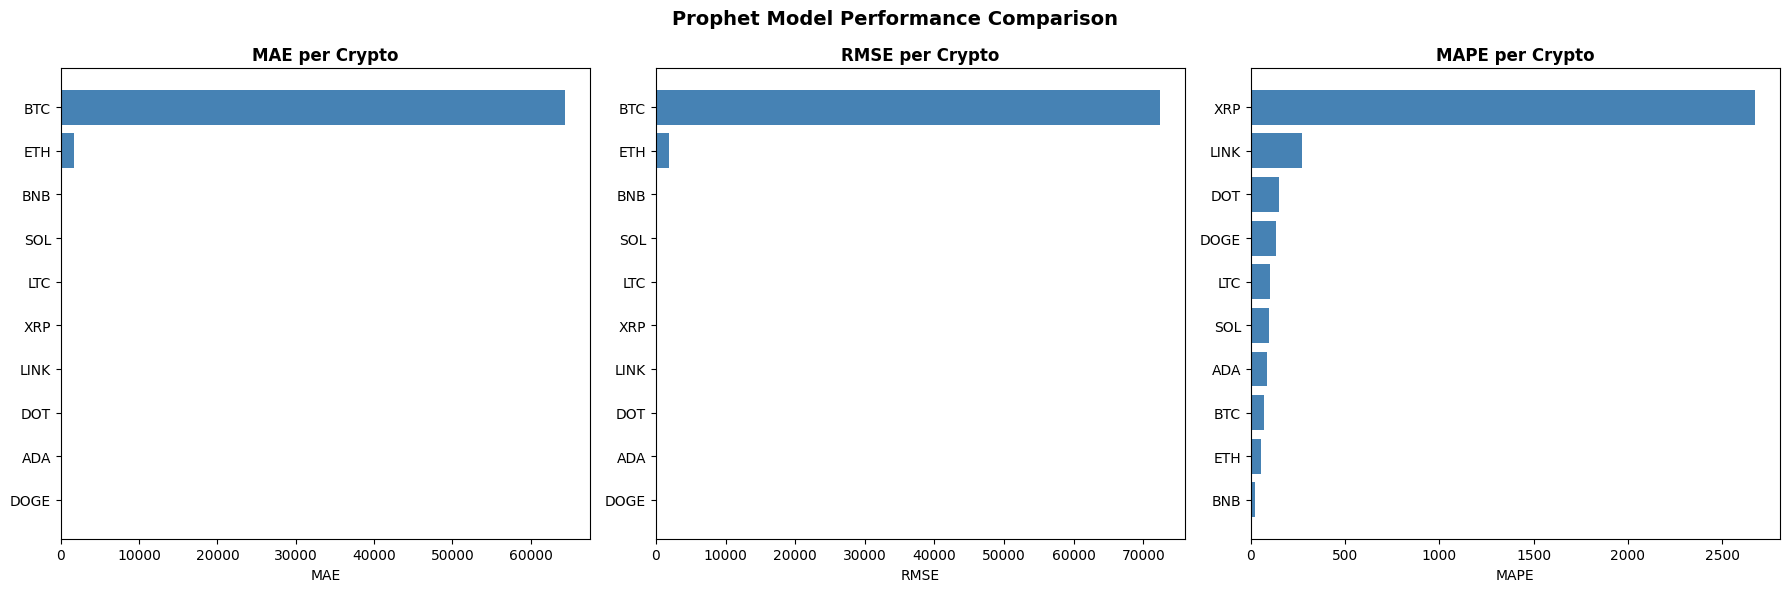

Saved: model_performance_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    sorted_df = metrics_df.sort_values(metric)
    ax.barh(sorted_df["Crypto"], sorted_df[metric], color="steelblue")
    ax.set_title(f"{metric} per Crypto", fontweight="bold")
    ax.set_xlabel(metric)

plt.suptitle("Prophet Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{output_dir}/model_performance_comparison.png", dpi=150)
plt.show()
print("Saved: model_performance_comparison.png")

## Generate Individual Future CSV Files
Save a separate `_future.csv` file for each cryptocurrency containing
only the 180-day future forecast period.
These individual files are used in the Power BI dashboard for per-coin analysis.

In [15]:

output_dir    = "../data/forecasts/prophet"
FORECAST_DAYS = 180

combined = pd.read_csv(f"{output_dir}/combined_forecast.csv", parse_dates=["Date"])

for crypto in combined["Crypto"].unique():
    future_only = combined[combined["Crypto"] == crypto].tail(FORECAST_DAYS)
    future_only.to_csv(f"{output_dir}/{crypto}_future.csv", index=False)
    print(f"Saved: {crypto}_future.csv")

print(f"\nTotal files now: {len(os.listdir(output_dir))}")

Saved: ADA_future.csv
Saved: BNB_future.csv
Saved: BTC_future.csv
Saved: DOGE_future.csv
Saved: DOT_future.csv
Saved: ETH_future.csv
Saved: LINK_future.csv
Saved: LTC_future.csv
Saved: SOL_future.csv
Saved: XRP_future.csv

Total files now: 44


## Summary

| Output | Description | Location |
|--------|-------------|----------|
| {CRYPTO}_forecast.csv | Full forecast per coin | data/forecasts/prophet/ |
| {CRYPTO}_forecast.png | Forecast chart per coin | data/forecasts/prophet/ |
| {CRYPTO}_components.png | Trend & seasonality components | data/forecasts/prophet/ |
| {CRYPTO}_future.csv | Future 180 days only per coin | data/forecasts/prophet/ |
| BTC_cross_validation.csv | BTC cross-validation metrics | data/forecasts/prophet/ |
| combined_forecast.csv | All 10 cryptos combined | data/forecasts/prophet/ |
| model_metrics.csv | MAE, RMSE, MAPE per crypto | data/forecasts/prophet/ |
| model_performance_comparison.png | Performance bar charts | data/forecasts/prophet/ |

**Key Findings:**
- Prophet performs best on BNB (MAPE ~20%) and worst on XRP (MAPE ~2673%)
- XRP's extreme volatility from regulatory events makes it unpredictable for Prophet
- Prophet is designed for stable business metrics — crypto volatility is challenging
- Average MAPE across all coins: ~365% (heavily skewed by XRP outlier)

**Next Step:** `06_arima_forecasting.ipynb`